# Global Superstore - End-to-End E-Commerce Analytics

**Data:** the real Tableau *Global Superstore* extract - 51,290 order lines, 25,754 orders,
795 customers, 147 countries, Jan 2011 - Dec 2014.

This notebook is the analysis narrative. The reproducible pipeline lives in `src/`
(`data_cleaning.py` -> `feature_engineering.py` -> `rfm_analysis.py`); this notebook
imports its outputs rather than re-deriving them, so the numbers here, the numbers in the
SQL layer and the numbers in the Power BI model all come from one source.

**Every figure below answers a stated business question.** Charts that would only decorate
the page are deliberately absent.

### What this dataset can and cannot answer

The single most important thing to know before reading any customer chart: **this is a
closed panel, not an acquisition funnel.** All 795 customers were acquired during 2011,
every one of them placed at least 15 orders, and the median customer was last active 16
days before the snapshot. Section 8 quantifies exactly which conventional e-commerce
metrics that makes meaningless. They are reported as unanswerable rather than filled in
with a plausible-looking chart.

---
## 1. Business Problem

A global retailer sells furniture, office supplies and technology across seven markets. It
is growing - revenue rose from \$2.26M in 2011 to \$4.30M in 2014 - but growth alone does
not tell management where money is being made or lost.

The questions this analysis answers:

| # | Question | Where answered |
|---|---|---|
| 1 | How is the business performing overall, and is growth accelerating? | S4 |
| 2 | Which categories and sub-categories generate revenue vs *profit*? | S6 |
| 3 | Which regions and markets perform best, and which destroy value? | S6 |
| 4 | Do discounts actually buy revenue, or just give away margin? | S6, S13 |
| 5 | Which products are high-revenue but low-profit (the dangerous quadrant)? | S13 |
| 6 | Who are the most valuable customers, and is revenue concentrated? | S8 |
| 7 | Which customers are disengaging, and what should be done per segment? | S9 |
| 8 | Does retention decay, and what does a cohort curve mean on a closed panel? | S10 |
| 9 | Where do returns and fulfilment delays cluster? | S14 |
| 10 | What concrete actions follow, each tied to a number? | S15, S16 |

Two questions in the original brief - payment-method mix and cancellation rate - **cannot
be answered**: the dataset records neither. They are listed as omissions rather than
approximated.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

# Resolve the project root by walking up until data/raw is visible, so the
# notebook runs from any working directory.
ROOT = Path.cwd()
while not (ROOT / "data" / "raw").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# ---- Presentation rules (brief section 16): clean, minimal, no decoration ----
PALETTE = {
    "ink":     "#1f2933",
    "primary": "#1f4e79",
    "accent":  "#2e8b8b",
    "warn":    "#c0563f",
    "muted":   "#9aa5b1",
    "grid":    "#e4e7eb",
}
CATEGORICAL = ["#1f4e79", "#2e8b8b", "#c0563f", "#7b6d8d", "#c99700", "#5c8001"]

mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "savefig.bbox": "tight",
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.labelsize": 10,
    "axes.labelcolor": PALETTE["ink"],
    "axes.edgecolor": PALETTE["muted"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
    "text.color": PALETTE["ink"],
    "xtick.color": PALETTE["ink"],
    "ytick.color": PALETTE["ink"],
    "legend.frameon": False,
})
sns.set_palette(CATEGORICAL)

FIG_INDEX: dict[str, str] = {}


def save_fig(fig, name: str, question: str) -> None:
    """Persist a figure and record the business question it answers."""
    path = FIGURES / f"{name}.png"
    fig.savefig(path)
    FIG_INDEX[name] = question
    print(f"saved reports/figures/{name}.png  <- {question}")


def money(x, pos=None) -> str:
    if abs(x) >= 1_000_000:
        return f"${x/1_000_000:,.1f}M"
    if abs(x) >= 1_000:
        return f"${x/1_000:,.0f}K"
    return f"${x:,.0f}"


MONEY_FMT = mpl.ticker.FuncFormatter(money)
print(f"project root: {ROOT}")

project root: D:\DA-projects\ecommerce-analytics


---
## 2. Dataset Overview

Three sheets from one workbook: `Orders` (the transactions), `Returns` (which orders came
back) and `People` (regional managers). Nothing was downloaded twice and nothing was
synthesised - `data/raw/Global Superstore.xls` is the untouched source.

In [2]:
lines = pd.read_csv(PROCESSED / "orders_features.csv",
                    parse_dates=["order_date", "ship_date", "order_month_start"])
orders = pd.read_csv(PROCESSED / "orders_agg.csv", parse_dates=["order_date", "ship_date"])
customers = pd.read_csv(PROCESSED / "customer_metrics.csv",
                        parse_dates=["first_order_date", "last_order_date"])
monthly = pd.read_csv(PROCESSED / "monthly_kpis.csv")
rfm = pd.read_csv(PROCESSED / "rfm_segments.csv",
                  parse_dates=["first_order_date", "last_order_date"])
seg_summary = pd.read_csv(PROCESSED / "rfm_segment_summary.csv")
products = pd.read_csv(PROCESSED / "products.csv")
retention = pd.read_csv(PROCESSED / "cohort_retention.csv", index_col=0)
retention.columns = retention.columns.astype(int)

dq_facts = json.loads((ROOT / "reports" / "data_quality_facts.json").read_text(encoding="utf-8"))
seg_facts = json.loads((ROOT / "reports" / "segmentation_facts.json").read_text(encoding="utf-8"))

# discount_band loses its ordering through CSV; restore it so every chart and
# table orders the bands correctly rather than alphabetically.
BAND_ORDER = ["0% (none)", "1-10%", "11-20%", "21-30%", "31-50%", "51%+"]
lines["discount_band"] = pd.Categorical(lines["discount_band"], BAND_ORDER, ordered=True)

SNAPSHOT = lines["order_date"].max()

print(f"order lines : {len(lines):>8,} x {lines.shape[1]} columns")
print(f"orders      : {len(orders):>8,}")
print(f"customers   : {len(customers):>8,}")
print(f"products    : {len(products):>8,}")
print(f"months      : {len(monthly):>8,}  ({monthly['order_ym'].iat[0]} to {monthly['order_ym'].iat[-1]})")
print(f"snapshot    : {SNAPSHOT.date()}")

order lines :   51,290 x 48 columns
orders      :   25,754
customers   :      795
products    :   10,292
months      :       48  (2011-01 to 2014-12)
snapshot    : 2014-12-31


In [3]:
grain = pd.DataFrame({
    "grain": ["order line", "order", "customer", "product", "brand (derived)",
              "country", "market", "region", "category", "sub-category"],
    "distinct": [len(lines), orders["order_key"].nunique(), customers["customer_key"].nunique(),
                 lines["product_id"].nunique(), lines["brand"].nunique(),
                 lines["country"].nunique(), lines["market"].nunique(),
                 lines["region"].nunique(), lines["category"].nunique(),
                 lines["sub_category"].nunique()],
})
display(grain.style.hide(axis="index").format({"distinct": "{:,}"}))

grain,distinct
order line,"51,290"
order,"25,754"
customer,795
product,"10,292"
brand (derived),467
country,147
market,7
region,13
category,3
sub-category,17


---
## 3. Data Cleaning

`src/data_cleaning.py` produces the full audit at `reports/data_quality_report.md`. Rather
than restate it, here are the five decisions that actually changed the numbers, each driven
by evidence in that report:

| Decision | Evidence | Effect if done naively |
|---|---|---|
| **Resolve customer identity to the person** | All 795 names carry exactly 2 `customer_id`s - one for APAC/EU/LATAM/US, one for Africa/EMEA. `AB-10015` and `AB-15` are both Aaron Bergman. | Reporting 1,590 customers instead of 795; halving every customer's lifetime value; corrupting RFM, CLV and cohorts. |
| **Composite order key** | 659 `order_id`s appear against 2 different customers on 2 different dates. | 25,035 "orders" instead of 25,754 - inflating average order value. |
| **Drop nothing as duplicates** | 0 rows duplicate another on all business fields. All 38 `(order_id, product_id)` collisions were inspected: 28 split lines, 9 differ only in shipping cost, 1 different customer. | A reflexive `drop_duplicates()` would delete real revenue and real shipping cost. |
| **Round discount to 3dp, not 2dp** | `0.15000000000000002` is float noise, but `0.002 / 0.202 / 0.402 / 0.602` are genuine tiers on 629 lines. | Rounding to 2dp silently merges those tiers and erases a real pricing distinction. |
| **Join returns on `(order_id, market)`** | Returns labels the US `United States`; Orders says `US`. Joining on `order_id` alone flags 3,050 lines vs the correct 3,043. | 7 false-positive returns, inherited by reused order ids in markets with no returns data. |

Cleaning reconciled exactly: **51,290 rows in, 51,290 out**, and revenue, profit, quantity
and shipping cost are byte-identical before and after. Cleaning added keys and labels; it
removed nothing.

In [4]:
print("RECONCILIATION (from reports/data_quality_facts.json)")
print("=" * 62)
for k in ["raw_orders_rows", "clean_rows", "raw_customer_ids", "clean_customers",
          "orders_naive_key", "orders_composite_key", "duplicate_rows_business_fields",
          "collision_groups_unexplained", "discount_distinct_raw", "discount_distinct_3dp",
          "returns_lines_naive_join", "returns_lines_composite_join",
          "reconciliation_checks", "reconciliation_failures"]:
    print(f"  {k:<34} {dq_facts[k]:>10,}" if isinstance(dq_facts[k], (int, float))
          else f"  {k:<34} {dq_facts[k]}")

print()
print(f"  cost derivation           : revenue - profit  (exact; "
      f"{dq_facts['derived_cost_negatives']} impossible negatives)")
print(f"  revenue vs discount       : {dq_facts['discount_semantics_verdict'].upper()} of discount, "
      f"tested on {dq_facts['discount_semantics_products_tested']:,} products")
print(f"     median error if NET    : {dq_facts['discount_semantics_net_median_error']:.4%}")
print(f"     median error if GROSS  : {dq_facts['discount_semantics_gross_median_error']:.4%}")
print()
print(f"  returns coverage          : {dq_facts['returns_covered_markets']}")
print(f"  NO returns data for       : {dq_facts['returns_uncovered_markets']}  <- rate is UNKNOWN, never 0%")

RECONCILIATION (from reports/data_quality_facts.json)
  raw_orders_rows                        51,290
  clean_rows                             51,290
  raw_customer_ids                        1,590
  clean_customers                           795
  orders_naive_key                       25,035
  orders_composite_key                   25,754
  duplicate_rows_business_fields              0
  collision_groups_unexplained                0
  discount_distinct_raw                      29
  discount_distinct_3dp                      27
  returns_lines_naive_join                3,050
  returns_lines_composite_join            3,043
  reconciliation_checks                       8
  reconciliation_failures                     0

  cost derivation           : revenue - profit  (exact; 0 impossible negatives)
  revenue vs discount       : NET of discount, tested on 6,671 products
     median error if NET    : 0.0000%
     median error if GROSS  : 40.0000%

  returns coverage          : ['APAC', 'EU'

---
## 4. Exploratory Analysis - how is the business performing?

**Business question 1: what is the headline picture, and is growth accelerating or just
continuing?**

In [5]:
total_rev = lines["revenue"].sum()
total_cost = lines["cost"].sum()
total_profit = lines["profit"].sum()
total_ship = lines["shipping_cost"].sum()
total_disc = lines["discount_amount"].sum()
total_list = lines["list_revenue"].sum()
n_orders = orders["order_key"].nunique()

KPI = {
    "Total revenue": money(total_rev),
    "Total cost": money(total_cost),
    "Total profit": money(total_profit),
    "Profit margin": f"{total_profit / total_rev:.2%}",
    "Discount given": f"{money(total_disc)}  ({total_disc / total_list:.1%} of list)",
    "Shipping cost": f"{money(total_ship)}  ({total_ship / total_rev:.1%} of revenue)",
    "Orders": f"{n_orders:,}",
    "Customers": f"{customers['customer_key'].nunique():,}",
    "Average order value": money(orders["order_value"].mean()),
    "Units sold": f"{lines['quantity'].sum():,}",
    "Loss-making lines": f"{lines['is_loss_making'].sum():,}  ({lines['is_loss_making'].mean():.1%})",
}
for k, v in KPI.items():
    print(f"  {k:<22} {v}")

  Total revenue          $12.6M
  Total cost             $11.2M
  Total profit           $1.5M
  Profit margin          11.61%
  Discount given         $2.4M  (15.8% of list)
  Shipping cost          $1.4M  (10.7% of revenue)
  Orders                 25,754
  Customers              795
  Average order value    $491
  Units sold             178,312
  Loss-making lines      12,544  (24.5%)


saved reports/figures/01_monthly_revenue_profit.png  <- How is the business performing over time?


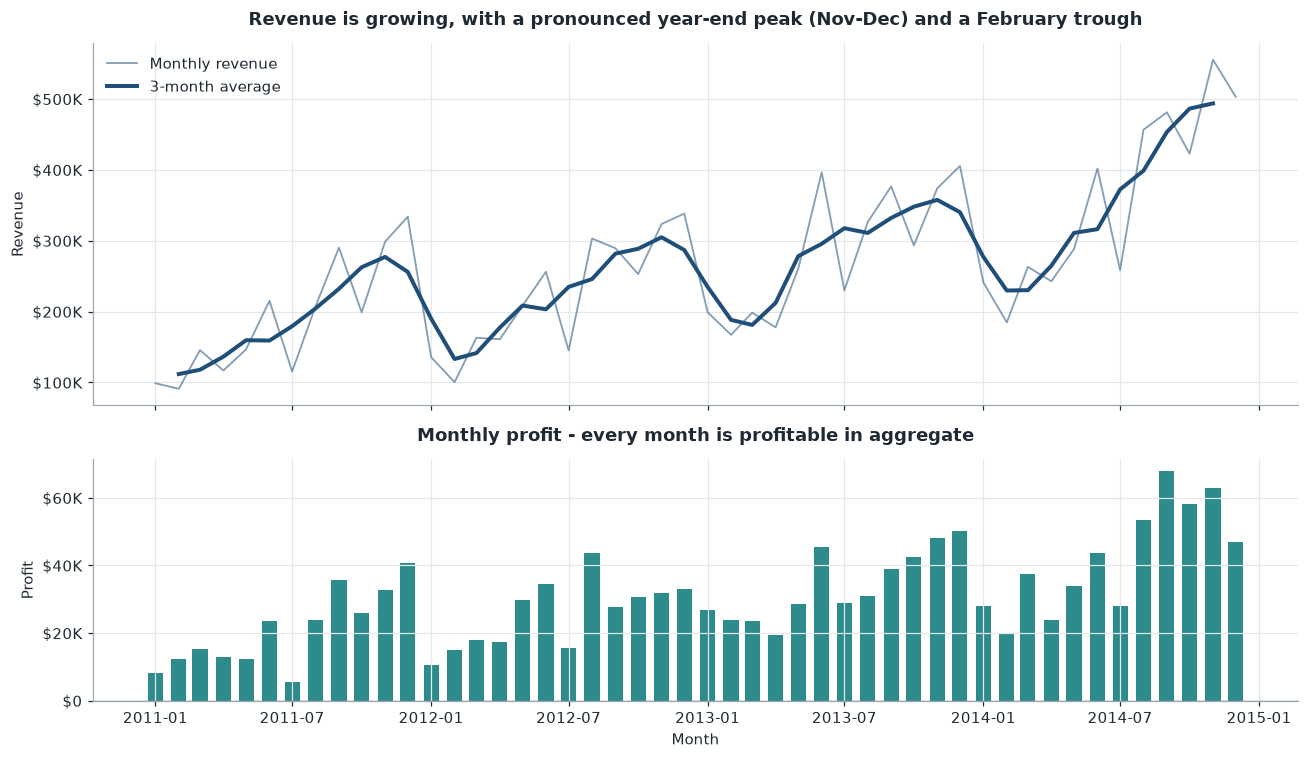

  peak month : 2014-11  $555K
  worst month: 2011-02  $91K
  months with negative profit: 0


In [6]:
# --- Figure 01: is the trend growth or noise? -------------------------------
m = monthly.copy()
m["month"] = pd.PeriodIndex(m["order_ym"], freq="M").to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={"height_ratios": [3, 2]})

ax = axes[0]
ax.plot(m["month"], m["revenue"], color=PALETTE["primary"], lw=1.2, alpha=.55,
        label="Monthly revenue")
ax.plot(m["month"], m["revenue"].rolling(3, center=True).mean(),
        color=PALETTE["primary"], lw=2.6, label="3-month average")
ax.yaxis.set_major_formatter(MONEY_FMT)
ax.set_title("Revenue is growing, with a pronounced year-end peak (Nov-Dec) "
             "and a February trough")
ax.set_ylabel("Revenue")
ax.legend(loc="upper left")

ax = axes[1]
colors = [PALETTE["accent"] if v >= 0 else PALETTE["warn"] for v in m["profit"]]
ax.bar(m["month"], m["profit"], width=20, color=colors)
ax.axhline(0, color=PALETTE["ink"], lw=.8)
ax.yaxis.set_major_formatter(MONEY_FMT)
ax.set_title("Monthly profit - every month is profitable in aggregate")
ax.set_ylabel("Profit")
ax.set_xlabel("Month")

fig.tight_layout()
save_fig(fig, "01_monthly_revenue_profit",
         "How is the business performing over time?")
plt.show()

print(f"  peak month : {m.loc[m['revenue'].idxmax(), 'order_ym']}  "
      f"{money(m['revenue'].max())}")
print(f"  worst month: {m.loc[m['revenue'].idxmin(), 'order_ym']}  "
      f"{money(m['revenue'].min())}")
print(f"  months with negative profit: {int((m['profit'] < 0).sum())}")

saved reports/figures/02_yearly_growth.png  <- Is growth accelerating, and is margin improving with scale?


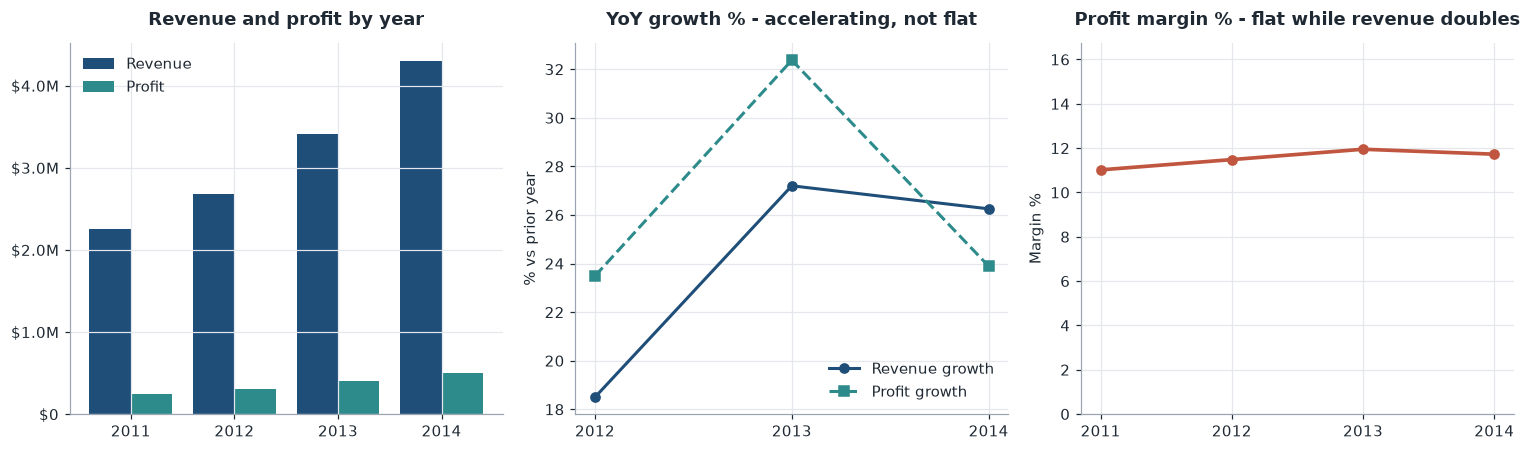

,revenue,profit,margin_pct,orders,aov,revenue_growth_pct,profit_growth_pct
order_year,,,,,,,
2011,"$2,259,451","$248,941",11.02%,"4,516",$500,+nan%,+nan%
2012,"$2,677,439","$307,415",11.48%,"5,480",$489,+18.5%,+23.5%
2013,"$3,405,746","$406,935",11.95%,"6,890",$494,+27.2%,+32.4%
2014,"$4,299,866","$504,166",11.73%,"8,868",$485,+26.3%,+23.9%


In [7]:
# --- Figure 02: growth by year, and is it accelerating? ---------------------
yearly = (lines.groupby("order_year")
          .agg(revenue=("revenue", "sum"), profit=("profit", "sum"),
               quantity=("quantity", "sum"))
          .assign(margin_pct=lambda d: d["profit"] / d["revenue"] * 100))
yearly["orders"] = orders.groupby("order_year")["order_key"].nunique()
yearly["revenue_growth_pct"] = yearly["revenue"].pct_change() * 100
yearly["profit_growth_pct"] = yearly["profit"].pct_change() * 100
yearly["aov"] = yearly["revenue"] / yearly["orders"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

ax = axes[0]
x = np.arange(len(yearly))
ax.bar(x - .2, yearly["revenue"], .4, label="Revenue", color=PALETTE["primary"])
ax.bar(x + .2, yearly["profit"], .4, label="Profit", color=PALETTE["accent"])
ax.set_xticks(x, yearly.index)
ax.yaxis.set_major_formatter(MONEY_FMT)
ax.set_title("Revenue and profit by year")
ax.legend()

ax = axes[1]
ax.plot(yearly.index[1:], yearly["revenue_growth_pct"].iloc[1:], "o-",
        color=PALETTE["primary"], lw=2, label="Revenue growth")
ax.plot(yearly.index[1:], yearly["profit_growth_pct"].iloc[1:], "s--",
        color=PALETTE["accent"], lw=2, label="Profit growth")
ax.set_title("YoY growth % - accelerating, not flat")
ax.set_ylabel("% vs prior year")
ax.set_xticks(yearly.index[1:])
ax.legend()

ax = axes[2]
ax.plot(yearly.index, yearly["margin_pct"], "o-", color=PALETTE["warn"], lw=2.4)
ax.set_title("Profit margin % - flat while revenue doubles")
ax.set_ylabel("Margin %")
ax.set_xticks(yearly.index)
ax.set_ylim(0, max(yearly["margin_pct"]) * 1.4)

fig.tight_layout()
save_fig(fig, "02_yearly_growth", "Is growth accelerating, and is margin improving with scale?")
plt.show()

display(yearly[["revenue", "profit", "margin_pct", "orders", "aov",
                "revenue_growth_pct", "profit_growth_pct"]]
        .style.format({"revenue": "${:,.0f}", "profit": "${:,.0f}", "margin_pct": "{:.2f}%",
                       "orders": "{:,}", "aov": "${:,.0f}",
                       "revenue_growth_pct": "{:+.1f}%", "profit_growth_pct": "{:+.1f}%"}))

**Finding.** Revenue grew **90%** over four years (\$2.26M -> \$4.30M) and growth is
*accelerating* - 18.5%, 27.2%, then 26.3%. But margin never left the **11.0%-12.0%** band.
The business is buying growth without improving unit economics, which is the thread the
rest of this analysis pulls on.

---
## 5. Univariate Analysis

**Business question: what does a typical transaction look like, and where are the
distributions skewed enough to break averages?**

saved reports/figures/03_univariate_distributions.png  <- What does a typical order, discount, margin and fulfilment lag look like?


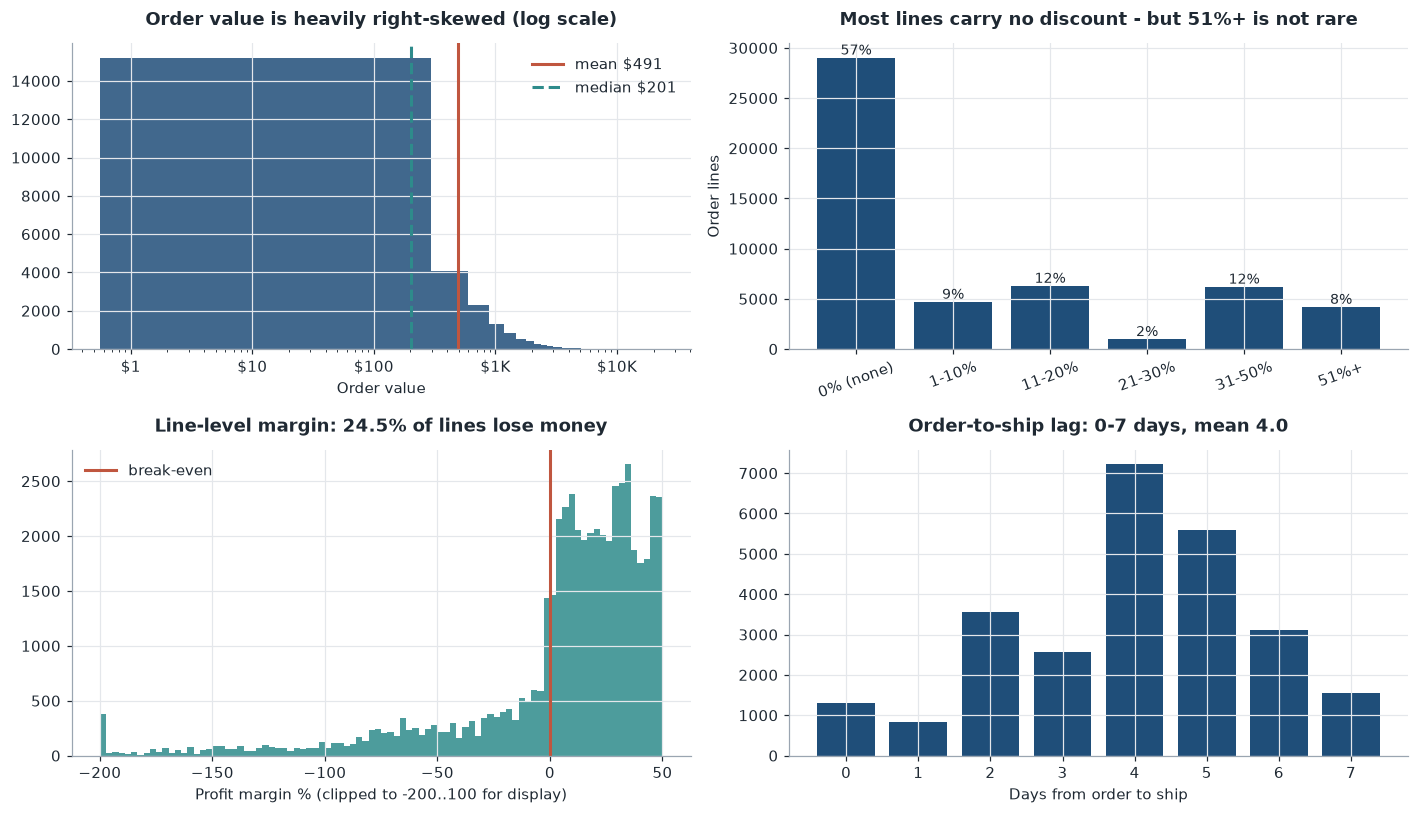

  order value  mean $491 vs median $201  -> mean is 2.4x the median
  95th pct order value: $2K
  lines at 51%+ discount: 4,172 (8.1%)


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))

ax = axes[0, 0]
ax.hist(orders["order_value"], bins=80, color=PALETTE["primary"], alpha=.85)
ax.axvline(orders["order_value"].mean(), color=PALETTE["warn"], lw=2,
           label=f"mean {money(orders['order_value'].mean())}")
ax.axvline(orders["order_value"].median(), color=PALETTE["accent"], lw=2, ls="--",
           label=f"median {money(orders['order_value'].median())}")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(MONEY_FMT)
ax.set_title("Order value is heavily right-skewed (log scale)")
ax.set_xlabel("Order value")
ax.legend()

ax = axes[0, 1]
band_counts = lines["discount_band"].value_counts().reindex(BAND_ORDER)
ax.bar(band_counts.index, band_counts.values, color=PALETTE["primary"])
ax.set_title("Most lines carry no discount - but 51%+ is not rare")
ax.set_ylabel("Order lines")
ax.tick_params(axis="x", rotation=20)
for i, v in enumerate(band_counts.values):
    ax.text(i, v, f"{v/len(lines):.0%}", ha="center", va="bottom", fontsize=9)

ax = axes[1, 0]
mg = lines["profit_margin_pct"].clip(-200, 100)
ax.hist(mg, bins=90, color=PALETTE["accent"], alpha=.85)
ax.axvline(0, color=PALETTE["warn"], lw=2, label="break-even")
ax.set_title(f"Line-level margin: {lines['is_loss_making'].mean():.1%} of lines lose money")
ax.set_xlabel("Profit margin % (clipped to -200..100 for display)")
ax.legend()

ax = axes[1, 1]
lag = lines.drop_duplicates("order_key")["ship_lag_days"]
ax.hist(lag, bins=range(0, 9), color=PALETTE["primary"], align="left", rwidth=.8)
ax.set_xticks(range(0, 8))
ax.set_title(f"Order-to-ship lag: 0-{int(lag.max())} days, mean {lag.mean():.1f}")
ax.set_xlabel("Days from order to ship")

fig.tight_layout()
save_fig(fig, "03_univariate_distributions",
         "What does a typical order, discount, margin and fulfilment lag look like?")
plt.show()

print(f"  order value  mean {money(orders['order_value'].mean())} vs "
      f"median {money(orders['order_value'].median())}  "
      f"-> mean is {orders['order_value'].mean()/orders['order_value'].median():.1f}x the median")
print(f"  95th pct order value: {money(orders['order_value'].quantile(.95))}")
print(f"  lines at 51%+ discount: {int((lines['discount'] > .5).sum()):,} "
      f"({(lines['discount'] > .5).mean():.1%})")

**Finding.** Average order value (\$491) is **2.44x the median** (\$201), so any KPI built on
the mean is being dragged by a thin tail of very large orders - the 95th percentile order is
\$1,915. Use the median for "typical", the mean only for capacity and revenue planning. And
**24.5% of order lines lose money** - that is the single biggest lever in this dataset.

---
## 6. Bivariate Analysis - where does profit actually come from?

**Business question 2 and 3: which categories, sub-categories and regions generate revenue
versus *profit*?** Ranking by revenue alone is how a business ends up scaling a loss.

saved reports/figures/04_category_profitability.png  <- Which categories and sub-categories generate profit, not just revenue?


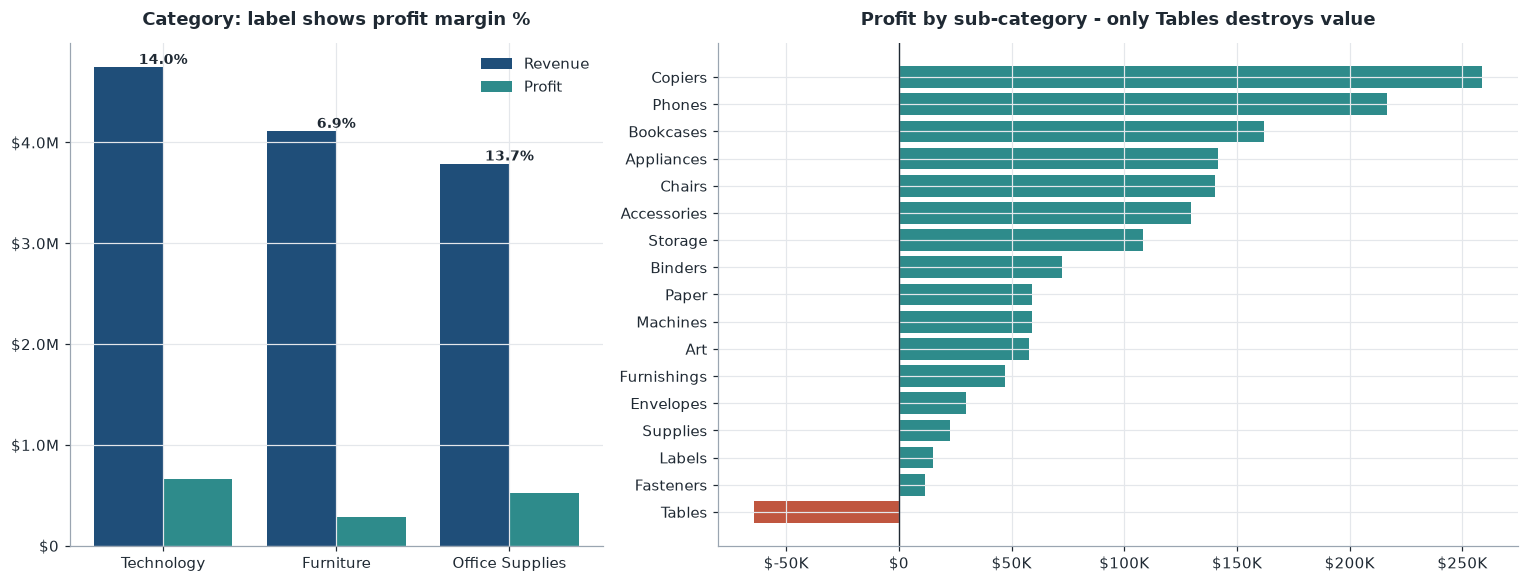

,revenue,profit,quantity,lines,margin_pct
category,,,,,
Technology,"$4,744,557","$663,779","35,176","10,141",13.99%
Furniture,"$4,110,874","$285,205","34,954","9,876",6.94%
Office Supplies,"$3,787,070","$518,474","108,182","31,273",13.69%



loss-making sub-categories: 1
  Tables         (Furniture      ) revenue     $757K  profit     $-64K  margin   -8.5%


In [9]:
# --- Figure 04: category / sub-category, revenue vs margin ------------------
cat = (lines.groupby("category")
       .agg(revenue=("revenue", "sum"), profit=("profit", "sum"),
            quantity=("quantity", "sum"), lines=("revenue", "size"))
       .assign(margin_pct=lambda d: d["profit"] / d["revenue"] * 100)
       .sort_values("revenue", ascending=False))

sub = (lines.groupby(["category", "sub_category"])
       .agg(revenue=("revenue", "sum"), profit=("profit", "sum"))
       .assign(margin_pct=lambda d: d["profit"] / d["revenue"] * 100)
       .reset_index().sort_values("profit"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), gridspec_kw={"width_ratios": [1, 1.5]})

ax = axes[0]
x = np.arange(len(cat))
ax.bar(x - .2, cat["revenue"], .4, color=PALETTE["primary"], label="Revenue")
ax.bar(x + .2, cat["profit"], .4, color=PALETTE["accent"], label="Profit")
for i, (_, r) in enumerate(cat.iterrows()):
    ax.text(i, r["revenue"], f"{r['margin_pct']:.1f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
ax.set_xticks(x, cat.index)
ax.yaxis.set_major_formatter(MONEY_FMT)
ax.set_title("Category: label shows profit margin %")
ax.legend()

ax = axes[1]
colors = [PALETTE["warn"] if v < 0 else PALETTE["accent"] for v in sub["profit"]]
ax.barh(sub["sub_category"], sub["profit"], color=colors)
ax.axvline(0, color=PALETTE["ink"], lw=.9)
ax.xaxis.set_major_formatter(MONEY_FMT)
ax.set_title("Profit by sub-category - only Tables destroys value")
fig.tight_layout()
save_fig(fig, "04_category_profitability",
         "Which categories and sub-categories generate profit, not just revenue?")
plt.show()

display(cat.style.format({"revenue": "${:,.0f}", "profit": "${:,.0f}",
                          "quantity": "{:,}", "lines": "{:,}", "margin_pct": "{:.2f}%"}))
loss_sub = sub[sub["profit"] < 0]
print(f"\nloss-making sub-categories: {len(loss_sub)}")
for _, r in loss_sub.iterrows():
    print(f"  {r['sub_category']:<14} ({r['category']:<15}) "
          f"revenue {money(r['revenue']):>9}  profit {money(r['profit']):>9}  "
          f"margin {r['margin_pct']:6.1f}%")

saved reports/figures/05_market_region_performance.png  <- Which markets and regions perform best, and which lose money?


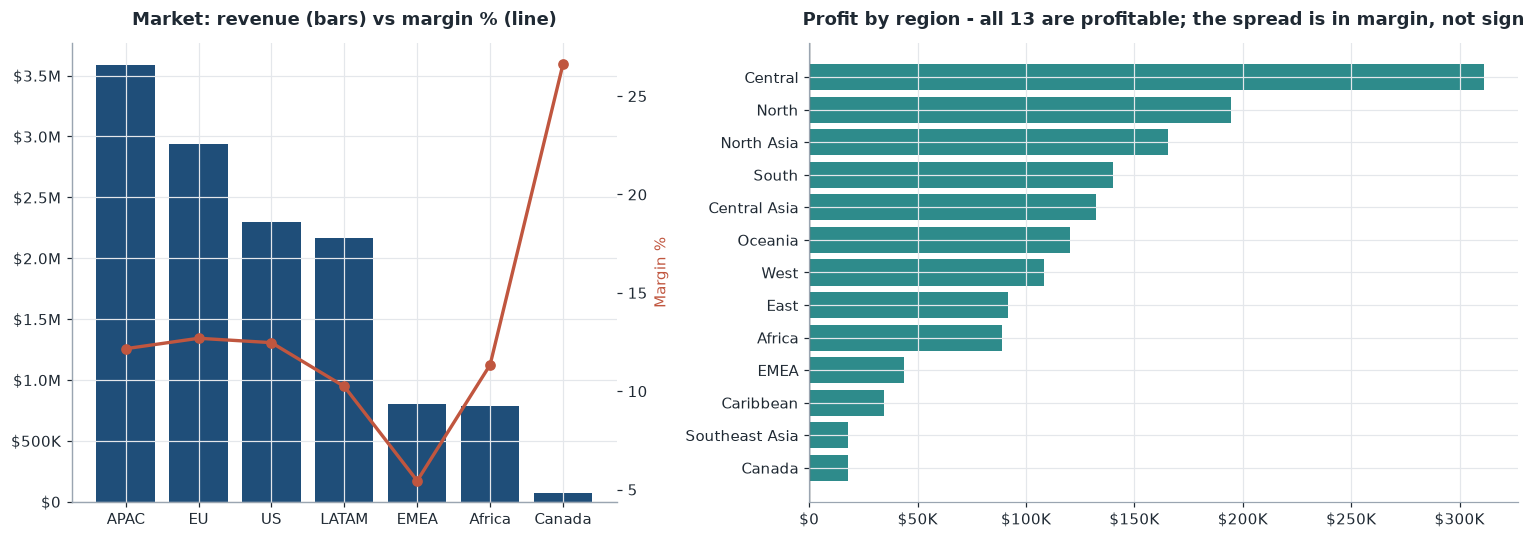

,revenue,profit,margin_pct
market,,,
APAC,"$3,585,744","$436,000",12.16%
EU,"$2,938,089","$372,830",12.69%
US,"$2,297,201","$286,397",12.47%
LATAM,"$2,164,605","$221,643",10.24%
EMEA,"$806,161","$43,898",5.45%
Africa,"$783,773","$88,872",11.34%
Canada,"$66,928","$17,817",26.62%



  loss-making regions: 0    loss-making markets: 0
  -> no region or market is negative at the full-period level, so this is a
     margin-quality problem, not a footprint-exit problem.

  thinnest margins (the real concern):
    Southeast Asia   revenue     $884K  profit      $18K  margin   2.02%
    EMEA             revenue     $806K  profit      $44K  margin   5.45%
    South            revenue     $1.6M  profit     $140K  margin   8.77%
    Caribbean        revenue     $324K  profit      $35K  margin  10.66%


In [10]:
# --- Figure 05: market and region ------------------------------------------
mkt = (lines.groupby("market")
       .agg(revenue=("revenue", "sum"), profit=("profit", "sum"))
       .assign(margin_pct=lambda d: d["profit"] / d["revenue"] * 100)
       .sort_values("revenue", ascending=False))
reg = (lines.groupby("region")
       .agg(revenue=("revenue", "sum"), profit=("profit", "sum"))
       .assign(margin_pct=lambda d: d["profit"] / d["revenue"] * 100)
       .sort_values("profit"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1.3]})

ax = axes[0]
x = np.arange(len(mkt))
ax.bar(x, mkt["revenue"], color=PALETTE["primary"], label="Revenue")
ax2 = ax.twinx()
ax2.plot(x, mkt["margin_pct"], "o-", color=PALETTE["warn"], lw=2.2, label="Margin %")
ax2.set_ylabel("Margin %", color=PALETTE["warn"])
ax2.grid(False)
ax.set_xticks(x, mkt.index)
ax.yaxis.set_major_formatter(MONEY_FMT)
ax.set_title("Market: revenue (bars) vs margin % (line)")

ax = axes[1]
colors = [PALETTE["warn"] if v < 0 else PALETTE["accent"] for v in reg["profit"]]
ax.barh(reg.index, reg["profit"], color=colors)
ax.axvline(0, color=PALETTE["ink"], lw=.9)
ax.xaxis.set_major_formatter(MONEY_FMT)
ax.set_title("Profit by region - all 13 are profitable; the spread is in margin, not sign")
fig.tight_layout()
save_fig(fig, "05_market_region_performance",
         "Which markets and regions perform best, and which lose money?")
plt.show()

display(mkt.style.format({"revenue": "${:,.0f}", "profit": "${:,.0f}", "margin_pct": "{:.2f}%"}))

n_neg_reg = int((reg["profit"] < 0).sum())
n_neg_mkt = int((mkt["profit"] < 0).sum())
print(f"\n  loss-making regions: {n_neg_reg}    loss-making markets: {n_neg_mkt}")
print("  -> no region or market is negative at the full-period level, so this is a")
print("     margin-quality problem, not a footprint-exit problem.")
print("\n  thinnest margins (the real concern):")
for name, r in reg.sort_values("margin_pct").head(4).iterrows():
    print(f"    {name:<16} revenue {money(r['revenue']):>9}  profit {money(r['profit']):>9}  "
          f"margin {r['margin_pct']:6.2f}%")

saved reports/figures/06_discount_effectiveness.png  <- Do discounts buy volume, or just give away margin?


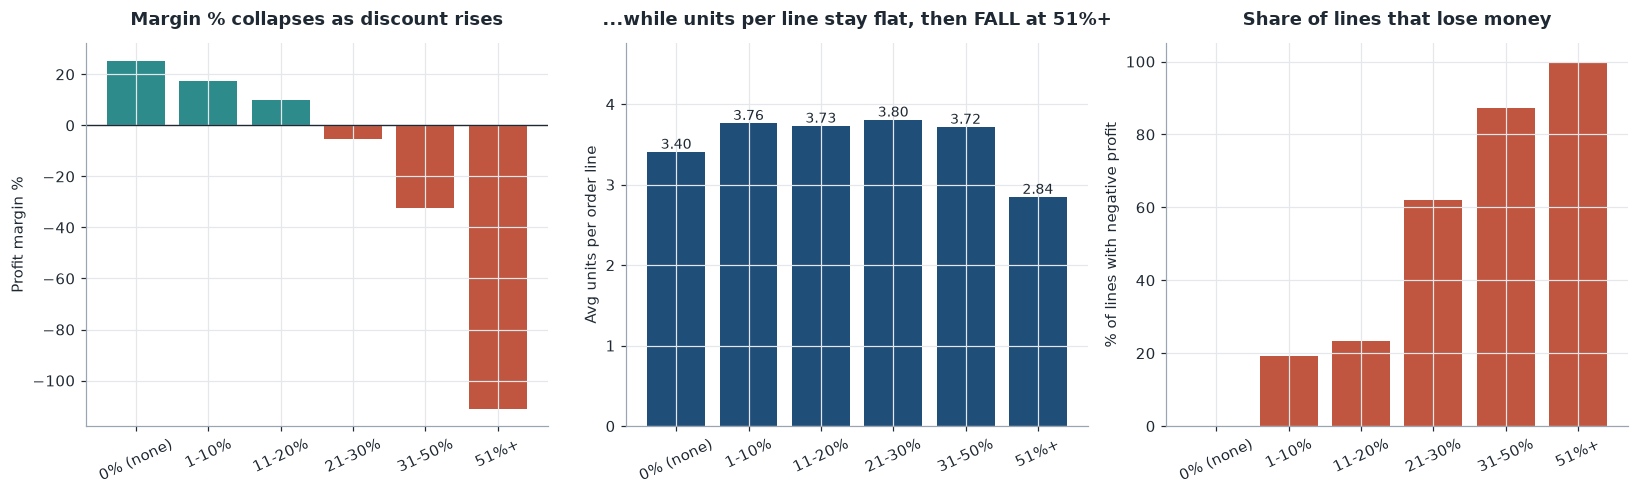

,lines_,revenue,profit,margin_pct,avg_qty,loss_rate,discount_given
discount_band,,,,,,,
0% (none),"29,009","$6,992,411","$1,770,695",25.3%,3.40,0.0%,$0
1-10%,"4,679","$1,962,619","$338,189",17.2%,3.76,19.3%,"$185,190"
11-20%,"6,274","$1,757,261","$173,255",9.9%,3.73,23.3%,"$405,635"
21-30%,967,"$382,555","$-21,156",-5.5%,3.80,62.2%,"$147,475"
31-50%,"6,189","$1,176,031","$-380,945",-32.4%,3.72,87.4%,"$898,056"
51%+,"4,172","$371,625","$-412,582",-111.0%,2.84,100.0%,"$727,632"


In [11]:
# --- Figure 06: the discount question -------------------------------------
band = (lines.groupby("discount_band", observed=True)
        .agg(lines_=("revenue", "size"), revenue=("revenue", "sum"),
             list_revenue=("list_revenue", "sum"), profit=("profit", "sum"),
             quantity=("quantity", "sum"), avg_qty=("quantity", "mean"),
             discount_given=("discount_amount", "sum"))
        .assign(margin_pct=lambda d: d["profit"] / d["revenue"] * 100,
                loss_rate=lambda d: np.nan))
band["loss_rate"] = (lines.groupby("discount_band", observed=True)["is_loss_making"]
                     .mean() * 100)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

ax = axes[0]
ax.bar(band.index.astype(str), band["margin_pct"],
       color=[PALETTE["accent"] if v >= 0 else PALETTE["warn"] for v in band["margin_pct"]])
ax.axhline(0, color=PALETTE["ink"], lw=.9)
ax.set_title("Margin % collapses as discount rises")
ax.set_ylabel("Profit margin %")
ax.tick_params(axis="x", rotation=25)

ax = axes[1]
ax.bar(band.index.astype(str), band["avg_qty"], color=PALETTE["primary"])
ax.set_title("...while units per line stay flat, then FALL at 51%+")
ax.set_ylabel("Avg units per order line")
ax.tick_params(axis="x", rotation=25)
ax.set_ylim(0, band["avg_qty"].max() * 1.25)
for i, v in enumerate(band["avg_qty"]):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

ax = axes[2]
ax.bar(band.index.astype(str), band["loss_rate"], color=PALETTE["warn"])
ax.set_title("Share of lines that lose money")
ax.set_ylabel("% of lines with negative profit")
ax.tick_params(axis="x", rotation=25)

fig.tight_layout()
save_fig(fig, "06_discount_effectiveness",
         "Do discounts buy volume, or just give away margin?")
plt.show()

display(band[["lines_", "revenue", "profit", "margin_pct", "avg_qty", "loss_rate",
              "discount_given"]]
        .style.format({"lines_": "{:,}", "revenue": "${:,.0f}", "profit": "${:,.0f}",
                       "margin_pct": "{:.1f}%", "avg_qty": "{:.2f}",
                       "loss_rate": "{:.1f}%", "discount_given": "${:,.0f}"}))

In [12]:
# Quantify the discount-volume claim properly rather than eyeballing the bars.
corr_qty = stats.spearmanr(lines["discount"], lines["quantity"])
corr_margin = stats.spearmanr(lines["discount"], lines["profit_margin_pct"])

print("Spearman rank correlation (line level, n = {:,})".format(len(lines)))
print(f"  discount vs quantity      rho = {corr_qty.statistic:+.4f}   p = {corr_qty.pvalue:.3g}")
print(f"  discount vs profit margin rho = {corr_margin.statistic:+.4f}   p = {corr_margin.pvalue:.3g}")

no_disc = lines[lines["discount"] == 0]
heavy = lines[lines["discount"] > 0.5]
print(f"\n  no discount   : {len(no_disc):>7,} lines | avg units {no_disc['quantity'].mean():.2f} "
      f"| margin {no_disc['profit'].sum()/no_disc['revenue'].sum():>7.2%}")
print(f"  51%+ discount : {len(heavy):>7,} lines | avg units {heavy['quantity'].mean():.2f} "
      f"| margin {heavy['profit'].sum()/heavy['revenue'].sum():>7.2%}")
print(f"\n  total discount given away: {money(lines['discount_amount'].sum())} "
      f"({lines['discount_amount'].sum()/lines['list_revenue'].sum():.1%} of list revenue)")
print(f"  profit lost on discounted lines vs break-even: "
      f"{money(lines.loc[lines['discount'] > 0, 'profit'].clip(upper=0).sum())}")

Spearman rank correlation (line level, n = 51,290)
  discount vs quantity      rho = +0.0177   p = 6.31e-05
  discount vs profit margin rho = -0.6691   p = 0

  no discount   :  29,009 lines | avg units 3.40 | margin  25.32%
  51%+ discount :   4,172 lines | avg units 2.84 | margin -111.02%

  total discount given away: $2.4M (15.8% of list revenue)
  profit lost on discounted lines vs break-even: $-921K


**Finding - the central commercial result.** Discounting **does not buy volume**. The rank
correlation between discount and quantity is +0.018 - statistically detectable only because
n = 51,290, and economically meaningless - while the correlation with margin is
**-0.67**. Units per line sit between 3.4 and 3.8 across every band from 0% to 50%, then
*fall* to 2.8 at 51%+. So the heaviest discounts are attached to *smaller* baskets, not
bigger ones.

The margin consequence is stark, and the loss rate is the cleanest way to see it:

| Discount band | Margin % | Lines that lose money |
|---|---:|---:|
| 0% (none) | **+25.3%** | **0.0%** |
| 1-10% | +17.2% | 19.3% |
| 11-20% | +9.9% | 23.3% |
| 21-30% | **-5.5%** | 62.2% |
| 31-50% | -32.4% | 87.4% |
| 51%+ | **-111.0%** | **100.0%** |

**Not one line at 0% discount loses money, and every single line above 50% does.** The
crossover is between 11-20% and 21-30%. The company gave away **\$2.36M (15.8% of list
revenue)** and bought no incremental units with it.

---
## 7. Correlation Analysis

**Business question: which measures move together, and which apparent relationships are
just arithmetic?** Revenue, cost and list revenue are definitionally linked, so the
interesting cells are the *behavioural* ones - discount, quantity, shipping and margin.

saved reports/figures/07_correlation_matrix.png  <- Which measures genuinely move together, once arithmetic links are set aside?


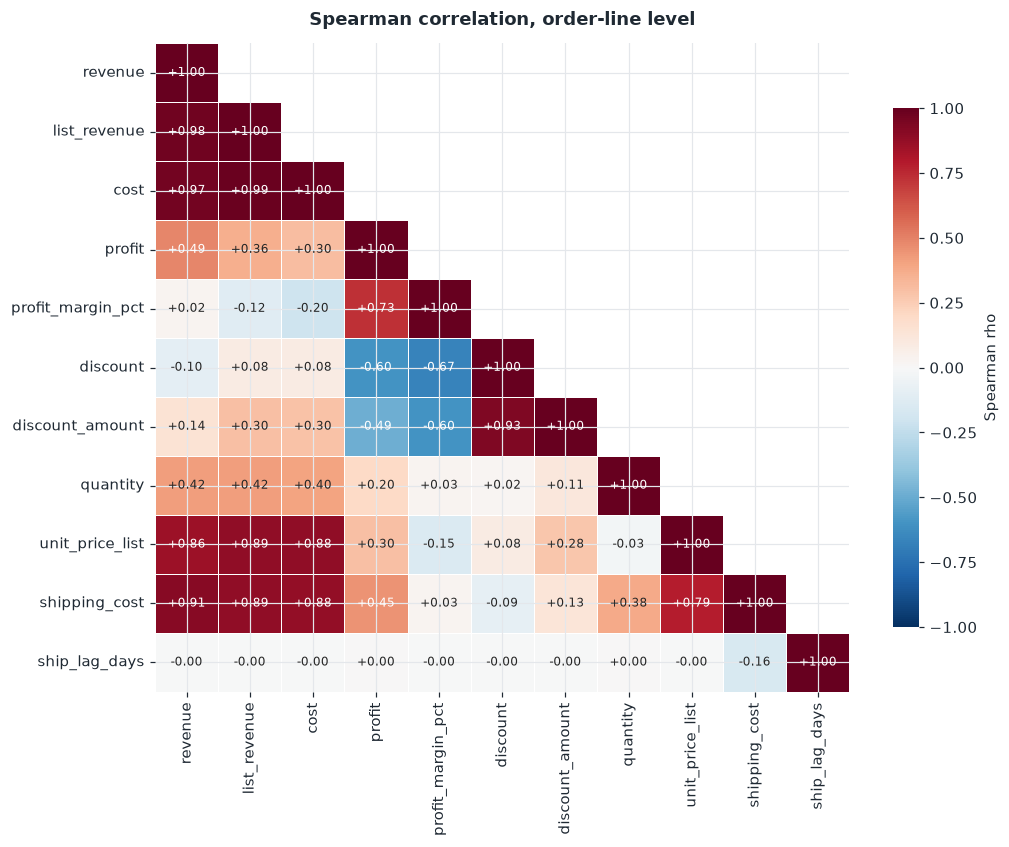

Behavioural relationships worth acting on:
  discount           vs profit_margin_pct    rho = -0.669
  discount           vs quantity             rho = +0.018
  unit_price_list    vs profit               rho = +0.298
  shipping_cost      vs profit               rho = +0.449
  ship_lag_days      vs profit_margin_pct    rho = -0.001
  quantity           vs revenue              rho = +0.416


In [13]:
num_cols = ["revenue", "list_revenue", "cost", "profit", "profit_margin_pct",
            "discount", "discount_amount", "quantity", "unit_price_list",
            "shipping_cost", "ship_lag_days"]
corr = lines[num_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9.5, 7.8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt="+.2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=.6, linecolor="white",
            cbar_kws={"label": "Spearman rho", "shrink": .8}, ax=ax,
            annot_kws={"fontsize": 8})
ax.set_title("Spearman correlation, order-line level")
fig.tight_layout()
save_fig(fig, "07_correlation_matrix",
         "Which measures genuinely move together, once arithmetic links are set aside?")
plt.show()

print("Behavioural relationships worth acting on:")
for a, b in [("discount", "profit_margin_pct"), ("discount", "quantity"),
             ("unit_price_list", "profit"), ("shipping_cost", "profit"),
             ("ship_lag_days", "profit_margin_pct"), ("quantity", "revenue")]:
    print(f"  {a:<18} vs {b:<20} rho = {corr.loc[a, b]:+.3f}")

**Finding.** Two things stand out. **Discount -> margin (rho -0.67) is the strongest
behavioural relationship in the dataset**, and **discount -> quantity is +0.02** - the same
result as Section 6, now confirmed across the full correlation structure. `ship_lag_days`
correlates with essentially nothing, which is genuinely useful: fulfilment speed is *not*
driving profitability here, so operational effort should go elsewhere.

---
## 8. Customer Segmentation - and what this dataset cannot tell us

**Business question 6: who are the most valuable customers, and is revenue concentrated?**

Before the segments: this is where the closed-panel structure has to be stated plainly,
because four metrics the brief asks for are **structurally uninformative** here.

In [14]:
print("SPEC METRICS THAT ARE DEGENERATE ON THIS DATASET")
print("=" * 76)
for k, v in seg_facts["degenerate_metrics"].items():
    print(f"\n  {k}")
    print(f"      {v}")

print("\n" + "=" * 76)
print("STRUCTURAL FACTS")
print("=" * 76)
print(f"  customers                        : {seg_facts['customers']:,}")
print(f"  one-time customers               : {seg_facts['one_time_customers']}")
print(f"  min / median / max orders each   : {seg_facts['min_order_frequency']} / "
      f"{seg_facts['median_order_frequency']:.0f} / {seg_facts['max_order_frequency']}")
print(f"  acquired after 2011              : {seg_facts['customers_acquired_after_2011']}")
print(f"  distinct acquisition cohorts     : {seg_facts['distinct_cohort_months']} (all in 2011)")
print(f"  dormant > 180 days               : {seg_facts['customers_dormant_over_180d']}")
print(f"  unprofitable customers           : {seg_facts['unprofitable_customers']} of "
      f"{seg_facts['customers']}")

SPEC METRICS THAT ARE DEGENERATE ON THIS DATASET

  repeat_purchase_rate
      100% - all 795 customers ordered at least 15 times. No variation to analyse.

  one_time_customers
      0 exist. The spec's one-time vs repeat split cannot be drawn.

  new_vs_returning
      0 customers acquired after 2011. From 2012 onward the base is 100% returning, 0% new.

  pareto_80_20
      Top 20% of customers hold 30.0% of revenue, not ~80%. Revenue is close to evenly spread, so 'focus on the top 20%' is not supported by this data.

  churn_and_lost
      Only 1 customer(s) dormant beyond 180 days (median 16 days). Churn analysis has almost no signal; 'Lost' is a relative label, not real attrition.

STRUCTURAL FACTS
  customers                        : 795
  one-time customers               : 0
  min / median / max orders each   : 15 / 32 / 47
  acquired after 2011              : 0
  distinct acquisition cohorts     : 12 (all in 2011)
  dormant > 180 days               : 1
  unprofitable customers

saved reports/figures/08_customer_concentration.png  <- Is revenue concentrated in a few customers, as the 80/20 rule assumes?


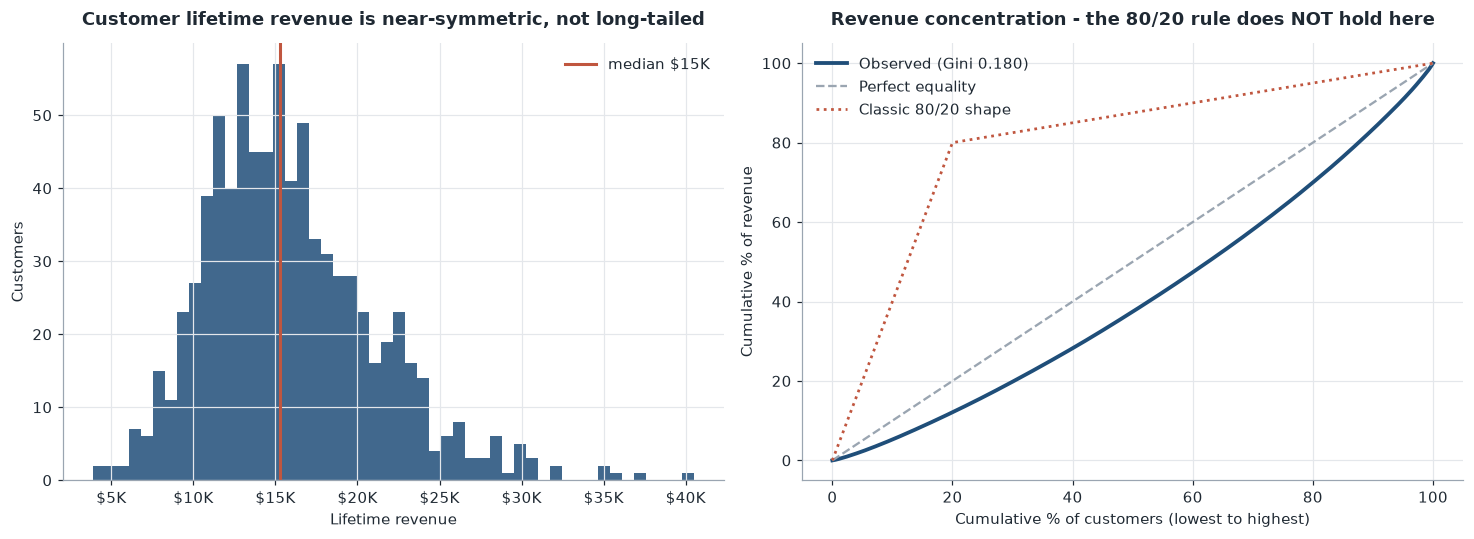

  Gini coefficient        : 0.180   (0 = perfectly equal, 1 = one customer holds all)
  top 10% of customers    : 16.5% of revenue
  top 20% of customers    : 30.0% of revenue   <- not 80%
  revenue range           : $4K to $40K  (10.4x)


In [15]:
# --- Figure 08: is revenue concentrated? (Lorenz curve + Gini) -------------
rev = customers["lifetime_revenue"].sort_values().to_numpy()
cum_rev = np.concatenate([[0], np.cumsum(rev) / rev.sum()])
cum_cust = np.linspace(0, 1, len(rev) + 1)
gini = 1 - 2 * np.trapezoid(cum_rev, cum_cust)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

ax = axes[0]
ax.hist(customers["lifetime_revenue"], bins=50, color=PALETTE["primary"], alpha=.85)
ax.axvline(customers["lifetime_revenue"].median(), color=PALETTE["warn"], lw=2,
           label=f"median {money(customers['lifetime_revenue'].median())}")
ax.xaxis.set_major_formatter(MONEY_FMT)
ax.set_title("Customer lifetime revenue is near-symmetric, not long-tailed")
ax.set_xlabel("Lifetime revenue")
ax.set_ylabel("Customers")
ax.legend()

ax = axes[1]
ax.plot(cum_cust * 100, cum_rev * 100, color=PALETTE["primary"], lw=2.5,
        label=f"Observed (Gini {gini:.3f})")
ax.plot([0, 100], [0, 100], ls="--", color=PALETTE["muted"], lw=1.5,
        label="Perfect equality")
# Where a classic 80/20 business would sit, for contrast.
ax.plot([0, 20, 100], [0, 80, 100], ls=":", color=PALETTE["warn"], lw=1.8,
        label="Classic 80/20 shape")
ax.set_xlabel("Cumulative % of customers (lowest to highest)")
ax.set_ylabel("Cumulative % of revenue")
ax.set_title("Revenue concentration - the 80/20 rule does NOT hold here")
ax.legend(loc="upper left")

fig.tight_layout()
save_fig(fig, "08_customer_concentration",
         "Is revenue concentrated in a few customers, as the 80/20 rule assumes?")
plt.show()

top20 = customers["lifetime_revenue"].nlargest(int(len(customers) * .2)).sum()
top10 = customers["lifetime_revenue"].nlargest(int(len(customers) * .1)).sum()
tot = customers["lifetime_revenue"].sum()
print(f"  Gini coefficient        : {gini:.3f}   (0 = perfectly equal, 1 = one customer holds all)")
print(f"  top 10% of customers    : {top10/tot:.1%} of revenue")
print(f"  top 20% of customers    : {top20/tot:.1%} of revenue   <- not 80%")
print(f"  revenue range           : {money(customers['lifetime_revenue'].min())} to "
      f"{money(customers['lifetime_revenue'].max())}  "
      f"({customers['lifetime_revenue'].max()/customers['lifetime_revenue'].min():.1f}x)")

**Finding - this overturns the expected story.** The Gini coefficient is **0.18** and the top
20% of customers hold **30%** of revenue, not 80%. Lifetime revenue runs \$3.9K to \$40.5K -
roughly a 10x spread across the entire base, where a typical e-commerce book spans several
orders of magnitude. So the standard recommendation - "identify and protect your top 20%" -
**is not supported by this data**. There is no small set of whales to defend. Value has to
be created by fixing *product and discount economics*, which apply to every customer at
once, not by tiering the customer base.

In [16]:
# Top customers still matter operationally, even without concentration.
top_cust = (customers.sort_values("lifetime_revenue", ascending=False)
            .head(10)[["customer_key", "customer_segment", "primary_market",
                       "order_frequency", "lifetime_revenue", "lifetime_profit",
                       "avg_order_value", "profit_margin_pct"]])
print("TOP 10 CUSTOMERS BY REVENUE")
display(top_cust.style.hide(axis="index").format({
    "lifetime_revenue": "${:,.0f}", "lifetime_profit": "${:,.0f}",
    "avg_order_value": "${:,.0f}", "profit_margin_pct": "{:.1f}%", "order_frequency": "{:,}"}))

worst = (customers.sort_values("lifetime_profit")
         .head(10)[["customer_key", "customer_segment", "primary_market",
                    "order_frequency", "lifetime_revenue", "lifetime_profit",
                    "profit_margin_pct"]])
print("\nTHE 10 MOST UNPROFITABLE CUSTOMERS - high revenue, negative profit")
display(worst.style.hide(axis="index").format({
    "lifetime_revenue": "${:,.0f}", "lifetime_profit": "${:,.0f}",
    "profit_margin_pct": "{:.1f}%", "order_frequency": "{:,}"}))

unprof = customers[customers["lifetime_profit"] < 0]
print(f"\n  {len(unprof)} customers ({len(unprof)/len(customers):.1%}) are net unprofitable")
print(f"  they generated {money(unprof['lifetime_revenue'].sum())} of revenue "
      f"and {money(unprof['lifetime_profit'].sum())} of profit")

TOP 10 CUSTOMERS BY REVENUE


customer_key,customer_segment,primary_market,order_frequency,lifetime_revenue,lifetime_profit,avg_order_value,profit_margin_pct
TOM_ASHBROOK,Home Office,EU,30,"$40,488","$6,312","$1,350",15.6%
TAMARA_CHAND,Corporate,LATAM,36,"$37,457","$8,673","$1,040",23.2%
GREG_TRAN,Consumer,US,34,"$35,551","$5,214","$1,046",14.7%
CHRISTOPHER_CONANT,Consumer,APAC,39,"$35,187","$5,603",$902,15.9%
SEAN_MILLER,Home Office,EU,28,"$35,171",$-410,"$1,256",-1.2%
BART_WATTERS,Corporate,APAC,45,"$32,310","$3,596",$718,11.1%
NATALIE_FRITZLER,Consumer,EU,43,"$31,781","$1,543",$739,4.9%
FRED_HOPKINS,Corporate,EMEA,39,"$30,401","$4,609",$780,15.2%
JANE_WACO,Corporate,EU,40,"$30,288","$6,266",$757,20.7%
HUNTER_LOPEZ,Consumer,APAC,24,"$30,244","$7,817","$1,260",25.8%



THE 10 MOST UNPROFITABLE CUSTOMERS - high revenue, negative profit


customer_key,customer_segment,primary_market,order_frequency,lifetime_revenue,lifetime_profit,profit_margin_pct
CINDY_STEWART,Consumer,LATAM,23,"$13,430","$-6,152",-45.8%
LUKE_FOSTER,Consumer,EU,27,"$13,421","$-3,644",-27.2%
GRANT_THORNTON,Corporate,EU,27,"$20,225","$-3,578",-17.7%
CANDACE_MCMAHON,Corporate,EU,28,"$14,795","$-2,799",-18.9%
SKYE_NORLING,Home Office,LATAM,31,"$14,219","$-2,638",-18.6%
DENISE_MONTON,Corporate,EU,33,"$22,053","$-2,598",-11.8%
SHARELLE_ROACH,Home Office,EU,24,"$13,002","$-2,551",-19.6%
DAVID_BREMER,Corporate,US,20,"$6,274","$-2,271",-36.2%
SEAN_BRAXTON,Corporate,LATAM,27,"$20,514","$-1,897",-9.2%
JULIE_CREIGHTON,Corporate,EU,34,"$14,994","$-1,889",-12.6%



  67 customers (8.4%) are net unprofitable
  they generated $949K of revenue and $-66K of profit


---
## 9. RFM Analysis

**Business question 7: which customers are disengaging, and what should be done about each
group?**

Scoring is standard quintile RFM (`src/rfm_analysis.py`). Two honesty constraints are built
into the implementation:

- **"New Customers" is gated on acquisition tenure, not low frequency.** A frequency-based
  rule labelled 91 customers as "new" who were all acquired in 2011 with 17-31 orders each.
  Tenure-gating correctly returns **zero** - and the empty segment is shown rather than
  quietly dropped.
- **Every label ships with its actual R/F/M range** and a caveat column, because "Lost" here
  means a median of 49 days dormant in a panel whose overall median is 16 - not churn.

saved reports/figures/09_rfm_segments.png  <- How does the customer base split by engagement and value, and what is each worth?


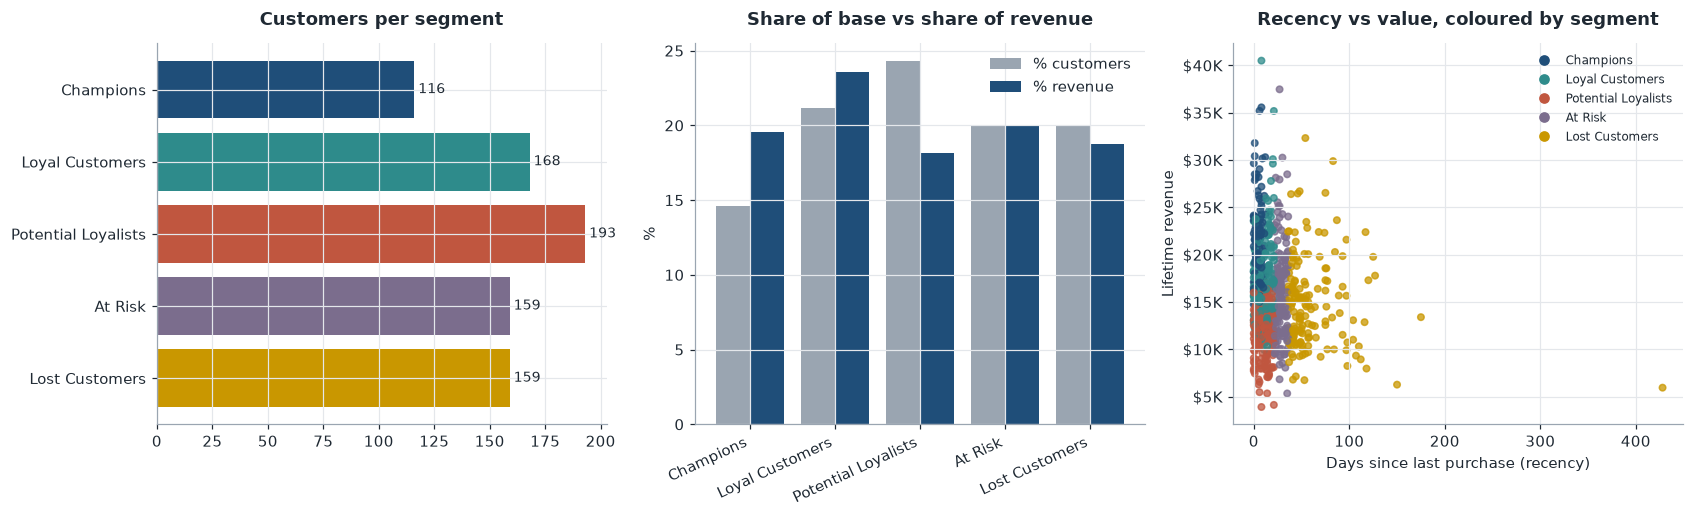

segment,customers,pct_customers,pct_revenue,avg_revenue,avg_orders,recency_min,recency_median,recency_max,margin_pct,unprofitable
Champions,116,14.6%,19.6%,"$21,312",37.6,0,5,12,12.1%,4
Loyal Customers,168,21.1%,23.6%,"$17,760",34.7,0,12,22,11.1%,16
Potential Loyalists,193,24.3%,18.1%,"$11,886",28.3,0,9,22,11.2%,19
New Customers,0,0.0%,-,-,-,-,-,-,-,-
At Risk,159,20.0%,20.0%,"$15,864",32.8,22,28,36,12.3%,13
Lost Customers,159,20.0%,18.7%,"$14,907",30.8,36,49,428,11.4%,15


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8))
present = seg_summary[seg_summary["customers"] > 0]
seg_colors = dict(zip(present["segment"], CATEGORICAL))

ax = axes[0]
ax.barh(present["segment"], present["customers"],
        color=[seg_colors[s] for s in present["segment"]])
ax.set_title("Customers per segment")
ax.invert_yaxis()
for i, v in enumerate(present["customers"]):
    ax.text(v, i, f" {v}", va="center", fontsize=9)

ax = axes[1]
x = np.arange(len(present))
ax.bar(x - .2, present["pct_customers"], .4, color=PALETTE["muted"], label="% customers")
ax.bar(x + .2, present["pct_revenue"], .4, color=PALETTE["primary"], label="% revenue")
ax.set_xticks(x, present["segment"], rotation=25, ha="right")
ax.set_title("Share of base vs share of revenue")
ax.set_ylabel("%")
ax.legend()

ax = axes[2]
sc = ax.scatter(rfm["days_since_last_purchase"], rfm["lifetime_revenue"],
                c=[seg_colors.get(s, PALETTE["muted"]) for s in rfm["segment"]],
                s=18, alpha=.75)
ax.set_xlabel("Days since last purchase (recency)")
ax.set_ylabel("Lifetime revenue")
ax.yaxis.set_major_formatter(MONEY_FMT)
ax.set_title("Recency vs value, coloured by segment")
handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=s)
           for s, c in seg_colors.items()]
ax.legend(handles=handles, fontsize=8, loc="upper right")

fig.tight_layout()
save_fig(fig, "09_rfm_segments",
         "How does the customer base split by engagement and value, and what is each worth?")
plt.show()

display(seg_summary[["segment", "customers", "pct_customers", "pct_revenue", "avg_revenue",
                     "avg_orders", "recency_min", "recency_median", "recency_max",
                     "margin_pct", "unprofitable"]]
        .style.hide(axis="index").format({
            "customers": "{:,.0f}", "pct_customers": "{:.1f}%", "pct_revenue": "{:.1f}%",
            "avg_revenue": "${:,.0f}", "avg_orders": "{:.1f}", "recency_min": "{:.0f}",
            "recency_median": "{:.0f}", "recency_max": "{:.0f}", "margin_pct": "{:.1f}%",
            "unprofitable": "{:.0f}"}, na_rep="-"))

In [18]:
print("SEGMENT ACTIONS AND THE CAVEAT THAT TRAVELS WITH EACH LABEL")
print("=" * 78)
for _, r in seg_summary.iterrows():
    n = int(r["customers"])
    head = f"{r['segment']}  ({n:,} customers"
    head += f", {r['pct_revenue']:.1f}% of revenue)" if n else ", EMPTY)"
    print(f"\n{head}")
    print(f"   ACTION : {r['action']}")
    print(f"   CAVEAT : {r['label_caveat']}")

SEGMENT ACTIONS AND THE CAVEAT THAT TRAVELS WITH EACH LABEL

Champions  (116 customers, 19.6% of revenue)
   ACTION : Protect. Highest value and most recently active. Give early access to new ranges and priority fulfilment; do NOT spend discount here - they already buy at the best margins.
   CAVEAT : Relative label: top recency and value quintiles within this 795-customer panel.

Loyal Customers  (168 customers, 23.6% of revenue)
   ACTION : Grow basket size. Consistent buyers with room to move up. Cross-sell adjacent sub-categories and bundle the low-margin items they already buy.
   CAVEAT : Relative label: upper-middle recency and value within this panel.

Potential Loyalists  (193 customers, 18.1% of revenue)
   ACTION : Convert to loyal. Recently active but spending below their cohort. Targeted category offers and a second-order incentive are justified here.
   CAVEAT : Relative label: recent but below-panel-average value. Not 'new' - see New Customers.

New Customers  (0 custome

---
## 10. Cohort Analysis

**Business question 8: does retention decay over time?**

A word on what this chart actually measures. All 795 customers were acquired in 2011, and
each places ~32 orders across 48 months - roughly one order every six weeks. So a monthly
cohort grid is **not** measuring survival; it measures *the probability a customer happened
to buy in that particular month*. Expect a flat, noisy field rather than the familiar
decaying triangle, and read it accordingly.

saved reports/figures/10_cohort_retention_heatmap.png  <- Does customer retention decay month over month?


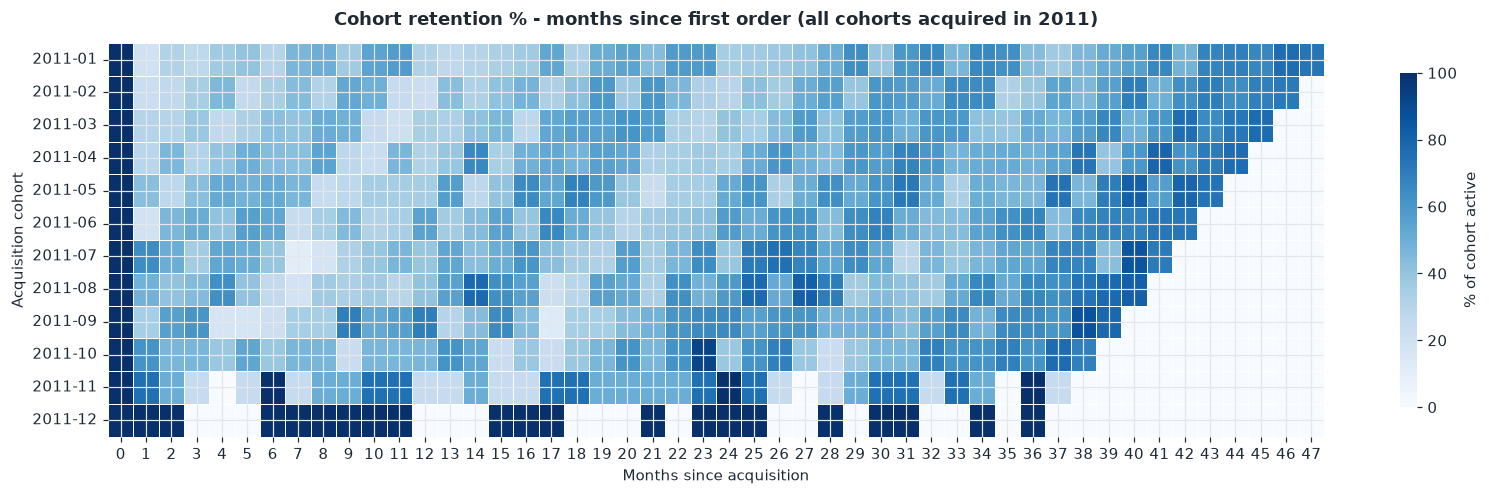

In [19]:
fig, ax = plt.subplots(figsize=(15, 4.6))
sns.heatmap(retention, cmap="Blues", vmin=0, vmax=100, linewidths=.4, linecolor="white",
            cbar_kws={"label": "% of cohort active", "shrink": .85}, ax=ax)
ax.set_title("Cohort retention % - months since first order (all cohorts acquired in 2011)")
ax.set_xlabel("Months since acquisition")
ax.set_ylabel("Acquisition cohort")
fig.tight_layout()
save_fig(fig, "10_cohort_retention_heatmap",
         "Does customer retention decay month over month?")
plt.show()

saved reports/figures/11_retention_trend.png  <- Is there a genuine retention decay, or just purchase-frequency noise?


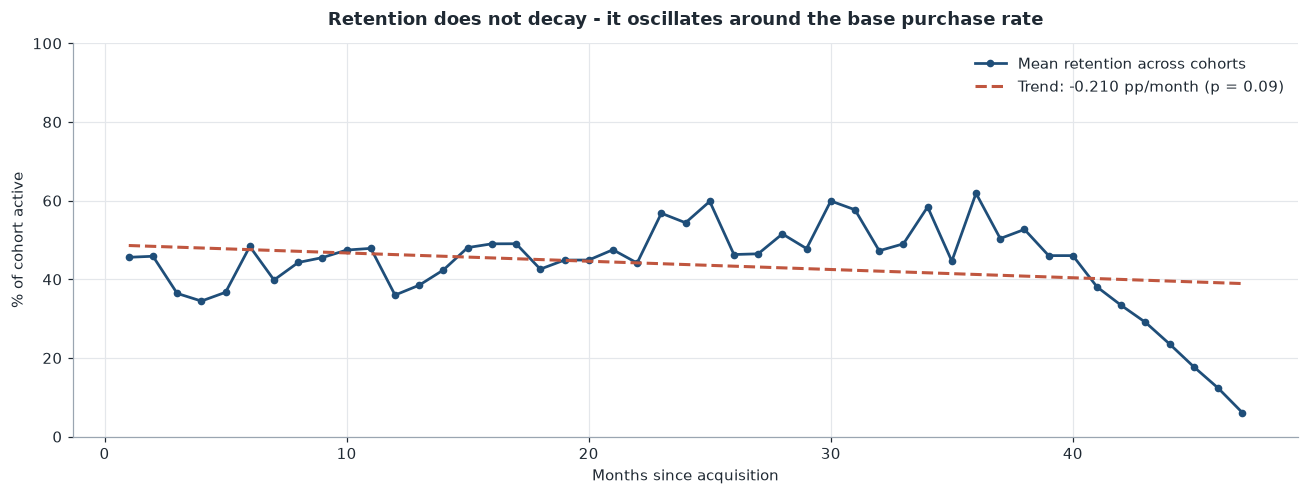

  mean retention, periods 1+     : 43.8%
  linear trend                   : -0.210 pp per month (p = 0.090)
  -> NO significant decay

  mean orders per customer       : 32.4 over 48 months
  implied monthly purchase rate  : 0.675 orders/month
  Poisson P(>=1 order in a month): 49.1%
  observed mean retention        : 43.8%

  Same order of magnitude, which is the point: the heatmap is tracking purchase
  cadence, not survival. Retention analysis has no churn signal on this panel.


In [20]:
# --- Figure 11: is there a decay trend at all? ----------------------------
avg_ret = retention.iloc[:, 1:].mean(axis=0)          # exclude period 0 (always 100%)
periods = avg_ret.index.to_numpy(dtype=float)
valid = avg_ret.notna().to_numpy()
slope, intercept, r_val, p_val, stderr = stats.linregress(
    periods[valid], avg_ret.to_numpy()[valid])

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.plot(avg_ret.index, avg_ret.values, "o-", color=PALETTE["primary"], lw=1.8, ms=4,
        label="Mean retention across cohorts")
ax.plot(periods, intercept + slope * periods, "--", color=PALETTE["warn"], lw=2,
        label=f"Trend: {slope:+.3f} pp/month (p = {p_val:.2f})")
ax.set_xlabel("Months since acquisition")
ax.set_ylabel("% of cohort active")
ax.set_ylim(0, 100)
ax.set_title("Retention does not decay - it oscillates around the base purchase rate")
ax.legend()
fig.tight_layout()
save_fig(fig, "11_retention_trend",
         "Is there a genuine retention decay, or just purchase-frequency noise?")
plt.show()

orders_per_cust = customers["order_frequency"].mean()
months_observed = 48
expected_monthly = 1 - np.exp(-orders_per_cust / months_observed)
print(f"  mean retention, periods 1+     : {avg_ret.mean():.1f}%")
print(f"  linear trend                   : {slope:+.3f} pp per month (p = {p_val:.3f})")
print(f"  -> {'NO significant decay' if p_val > 0.05 else 'significant trend'}")
print()
print(f"  mean orders per customer       : {orders_per_cust:.1f} over {months_observed} months")
print(f"  implied monthly purchase rate  : {orders_per_cust/months_observed:.3f} orders/month")
print(f"  Poisson P(>=1 order in a month): {expected_monthly:.1%}")
print(f"  observed mean retention        : {avg_ret.mean():.1f}%")
print("\n  Same order of magnitude, which is the point: the heatmap is tracking purchase")
print("  cadence, not survival. Retention analysis has no churn signal on this panel.")

**Finding.** Across 47 post-acquisition months there is **no significant retention decay**
(trend -0.21 percentage points per month, p = 0.09 - short of significance at the 5% level,
and the direction is driven by the ragged final periods where only the earliest cohorts have
data). Observed mean retention is **~44%**, against a Poisson expectation of **~49%** from
the average purchase rate of 0.67 orders per month. Those are the same order of magnitude,
which is the point: the cohort grid is tracking *purchase cadence*, not loyalty. On this
dataset cohort retention is the wrong tool, and saying so is more useful than shipping a
heatmap that implies churn insight it cannot support.

---
## 11. Advanced Analysis - the product profit quadrants

**Business question 5: which products earn revenue but destroy profit?** This is the
quadrant that matters most commercially, because scaling those products scales the loss.

saved reports/figures/12_product_quadrants.png  <- Which products are high-revenue but low-profit?


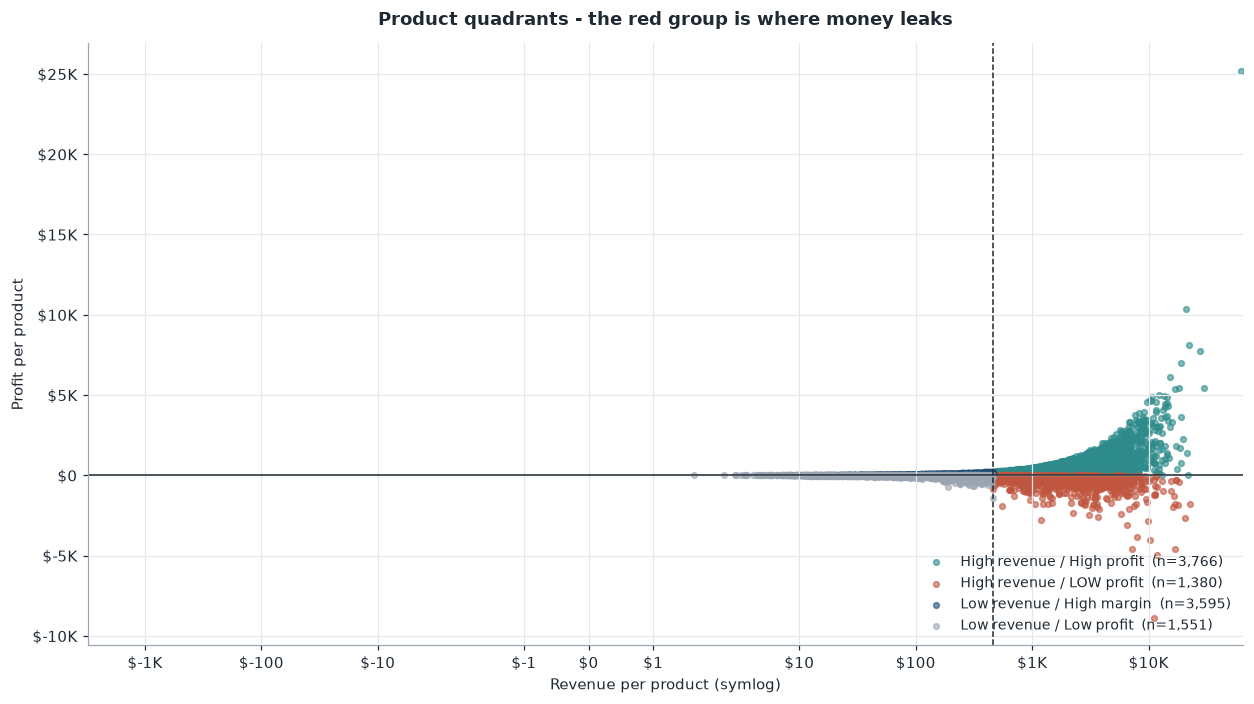

,products,revenue,profit,avg_discount,margin_pct
quadrant,,,,,
High revenue / High profit,"3,766","$8,660,218","$1,844,902",10.7%,21.3%
High revenue / LOW profit,"1,380","$3,037,191","$-461,720",23.0%,-15.2%
Low revenue / High margin,"3,595","$690,157","$166,853",10.1%,24.2%
Low revenue / Low profit,"1,551","$254,937","$-82,577",35.5%,-32.4%


In [21]:
prod = (lines.groupby("product_id")
        .agg(product=("product_label", "first"), category=("category", "first"),
             sub_category=("sub_category", "first"), brand=("brand", "first"),
             revenue=("revenue", "sum"), profit=("profit", "sum"),
             quantity=("quantity", "sum"), lines_=("revenue", "size"),
             avg_discount=("discount", "mean"))
        .assign(margin_pct=lambda d: d["profit"] / d["revenue"] * 100))

rev_median = prod["revenue"].median()
prod["quadrant"] = np.select(
    [(prod["revenue"] >= rev_median) & (prod["profit"] > 0),
     (prod["revenue"] >= rev_median) & (prod["profit"] <= 0),
     (prod["revenue"] < rev_median) & (prod["profit"] > 0)],
    ["High revenue / High profit", "High revenue / LOW profit",
     "Low revenue / High margin"],
    default="Low revenue / Low profit")

fig, ax = plt.subplots(figsize=(11.5, 6.5))
qcolors = {"High revenue / High profit": PALETTE["accent"],
           "High revenue / LOW profit": PALETTE["warn"],
           "Low revenue / High margin": PALETTE["primary"],
           "Low revenue / Low profit": PALETTE["muted"]}
for q, grp in prod.groupby("quadrant"):
    ax.scatter(grp["revenue"], grp["profit"], s=14, alpha=.6,
               color=qcolors[q], label=f"{q}  (n={len(grp):,})")
ax.axhline(0, color=PALETTE["ink"], lw=1)
ax.axvline(rev_median, color=PALETTE["ink"], lw=1, ls="--")
ax.set_xscale("symlog")
ax.set_xlabel("Revenue per product (symlog)")
ax.set_ylabel("Profit per product")
ax.xaxis.set_major_formatter(MONEY_FMT)
ax.yaxis.set_major_formatter(MONEY_FMT)
ax.set_title("Product quadrants - the red group is where money leaks")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
save_fig(fig, "12_product_quadrants",
         "Which products are high-revenue but low-profit?")
plt.show()

qsum = (prod.groupby("quadrant")
        .agg(products=("revenue", "size"), revenue=("revenue", "sum"),
             profit=("profit", "sum"), avg_discount=("avg_discount", "mean"))
        .assign(margin_pct=lambda d: d["profit"] / d["revenue"] * 100)
        .sort_values("revenue", ascending=False))
display(qsum.style.format({"products": "{:,}", "revenue": "${:,.0f}", "profit": "${:,.0f}",
                           "avg_discount": "{:.1%}", "margin_pct": "{:.1f}%"}))

In [22]:
danger = prod[prod["quadrant"] == "High revenue / LOW profit"].nsmallest(12, "profit")
print("THE 12 WORST HIGH-REVENUE / LOW-PROFIT PRODUCTS")
display(danger[["product", "sub_category", "revenue", "profit", "margin_pct",
                "quantity", "avg_discount"]]
        .style.hide(axis="index").format({
            "revenue": "${:,.0f}", "profit": "${:,.0f}", "margin_pct": "{:.0f}%",
            "quantity": "{:,}", "avg_discount": "{:.0%}"}))

best = prod.nlargest(10, "profit")
print("\nTOP 10 PRODUCTS BY PROFIT")
display(best[["product", "sub_category", "revenue", "profit", "margin_pct", "quantity"]]
        .style.hide(axis="index").format({
            "revenue": "${:,.0f}", "profit": "${:,.0f}", "margin_pct": "{:.0f}%",
            "quantity": "{:,}"}))

bad_q = prod[prod["quadrant"] == "High revenue / LOW profit"]
print(f"\n  {len(bad_q):,} products are high-revenue / low-profit")
print(f"  they carry {money(bad_q['revenue'].sum())} of revenue "
      f"({bad_q['revenue'].sum()/prod['revenue'].sum():.1%} of total)")
print(f"  and destroy {money(bad_q['profit'].sum())} of profit")
print(f"  their mean discount is {bad_q['avg_discount'].mean():.1%} vs "
      f"{prod.loc[prod['quadrant']=='High revenue / High profit', 'avg_discount'].mean():.1%} "
      f"for the healthy high-revenue group")

THE 12 WORST HIGH-REVENUE / LOW-PROFIT PRODUCTS


product,sub_category,revenue,profit,margin_pct,quantity,avg_discount
Cubify CubeX 3D Printer Double Head Print,Machines,"$11,100","$-8,880",-80%,9,53%
"Hoover Stove, White",Appliances,"$11,729","$-4,958",-42%,31,20%
Lexmark MX611dhe Monochrome Laser Printer,Machines,"$16,830","$-4,590",-27%,18,40%
"Apple Smart Phone, Full Size",Phones,"$7,259","$-4,575",-63%,20,36%
"Motorola Smart Phone, Cordless",Phones,"$10,349","$-3,999",-39%,24,19%
Cubify CubeX 3D Printer Triple Head Print,Machines,"$8,000","$-3,840",-48%,4,50%
"Office Star Executive Leather Armchair, Black",Chairs,"$6,497","$-3,067",-47%,22,28%
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,Tables,"$9,918","$-2,876",-29%,27,28%
"Lesro Computer Table, Fully Assembled",Tables,"$1,199","$-2,798",-233%,14,70%
Bush Advantage Collection Racetrack Conference Table,Tables,"$20,731","$-2,684",-13%,48,29%



TOP 10 PRODUCTS BY PROFIT


product,sub_category,revenue,profit,margin_pct,quantity
Canon imageCLASS 2200 Advanced Copier,Copiers,"$61,600","$25,200",41%,20
"Hoover Stove, Red",Appliances,"$21,147","$10,346",49%,38
"Nokia Smart Phone, Full Size",Phones,"$22,262","$8,121",36%,39
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,Binders,"$27,453","$7,753",28%,31
Hewlett Packard LaserJet 3310 Copier,Copiers,"$18,840","$6,984",37%,38
"Office Star Executive Leather Armchair, Black",Chairs,"$15,290","$6,123",40%,37
"Nokia Smart Phone, with Caller ID",Phones,"$30,042","$5,456",18%,52
"Hamilton Beach Stove, Silver",Appliances,"$18,248","$5,452",30%,38
"Samsung Smart Phone, VoIP",Phones,"$16,797","$5,357",32%,31
"SAFCO Executive Leather Armchair, Black",Chairs,"$12,301","$5,003",41%,30



  1,380 products are high-revenue / low-profit
  they carry $3.0M of revenue (24.0% of total)
  and destroy $-462K of profit
  their mean discount is 23.0% vs 10.7% for the healthy high-revenue group


---
## 12. Operations and Returns

**Business question 9: where do returns and fulfilment delays cluster?**

Returns are only recorded for **APAC, EU, LATAM and US**. Africa, Canada and EMEA have zero
return records, so their return rate is **unknown** - it is excluded from every rate below
rather than shown as 0%, which would invent a perfect returns record for a third of the
markets and understate the global figure.

  orders with returns measured : 20,717
  orders EXCLUDED (no data)    : 5,037 in ['Africa', 'Canada', 'EMEA']
  overall return rate (measured markets only) : 5.81%
  returned orders              : 1,203
  revenue on returned orders   : $818K


saved reports/figures/13_returns_analysis.png  <- Where do returns concentrate, in the markets where returns are actually recorded?


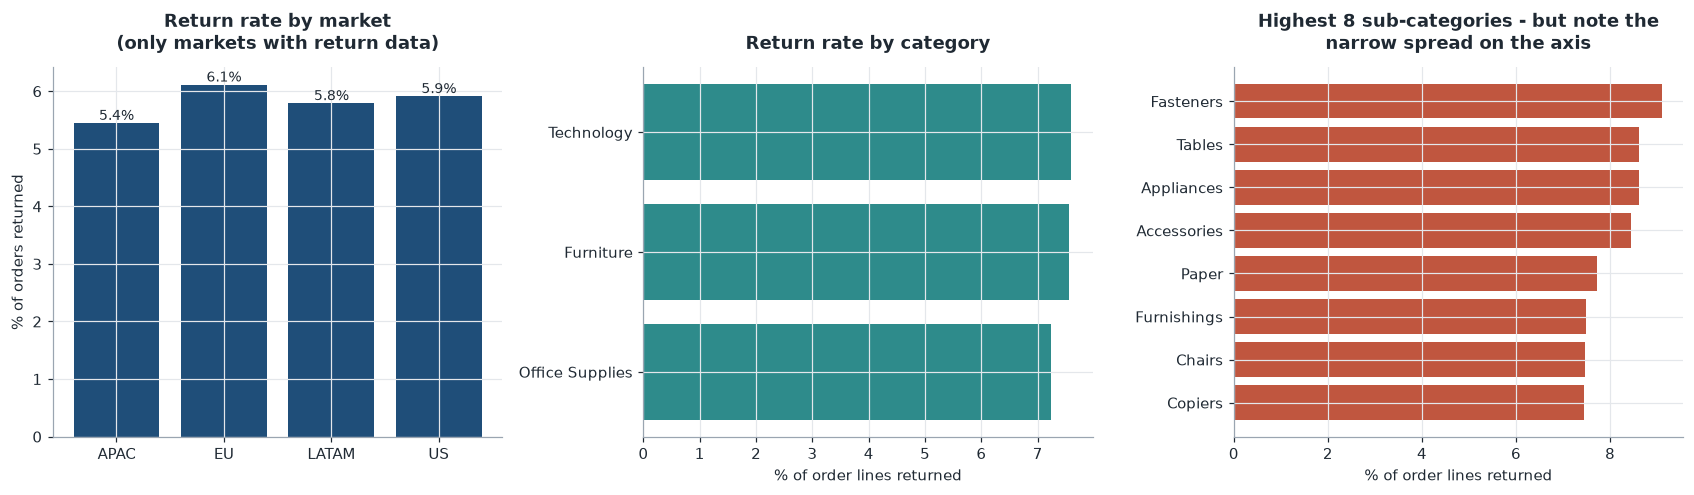


  line-level return rate, measured markets : 7.37%
  sub-category spread : 6.33% (Art) to 9.10% (Fasteners)
  worst / best ratio  : 1.44x
  market spread       : 5.44% to 6.11%

  -> There is NO returns hotspot. Rates sit in a narrow 6-9% band across every
     sub-category and a 5.4-6.2% band across every measured market. Returns look
     like a systemic cost of trading here, not a product-quality failure in one
     part of the range - so root-cause work has no obvious target to aim at.


In [23]:
measured = orders[orders["returns_measured"] == 1]
excluded = orders[orders["returns_measured"] == 0]
print(f"  orders with returns measured : {len(measured):,}")
print(f"  orders EXCLUDED (no data)    : {len(excluded):,} "
      f"in {sorted(excluded['market'].unique())}")
print(f"  overall return rate (measured markets only) : "
      f"{measured['return_flag'].mean():.2%}")
print(f"  returned orders              : {int(measured['return_flag'].sum()):,}")
print(f"  revenue on returned orders   : {money(measured.loc[measured['return_flag']==1, 'order_value'].sum())}")

lines_measured = lines[lines["returns_measured"] == 1]

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))

ax = axes[0]
by_mkt = measured.groupby("market")["return_flag"].agg(["mean", "size"])
ax.bar(by_mkt.index, by_mkt["mean"] * 100, color=PALETTE["primary"])
ax.set_title("Return rate by market\n(only markets with return data)")
ax.set_ylabel("% of orders returned")
for i, (v, n) in enumerate(zip(by_mkt["mean"] * 100, by_mkt["size"])):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

ax = axes[1]
by_cat = (lines_measured.groupby("category")["return_flag"].mean() * 100).sort_values()
ax.barh(by_cat.index, by_cat.values, color=PALETTE["accent"])
ax.set_title("Return rate by category")
ax.set_xlabel("% of order lines returned")

ax = axes[2]
by_sub = (lines_measured.groupby("sub_category")["return_flag"].mean() * 100
          ).sort_values().tail(8)
ax.barh(by_sub.index, by_sub.values, color=PALETTE["warn"])
ax.set_title("Highest 8 sub-categories - but note the\nnarrow spread on the axis")
ax.set_xlabel("% of order lines returned")

fig.tight_layout()
save_fig(fig, "13_returns_analysis",
         "Where do returns concentrate, in the markets where returns are actually recorded?")
plt.show()

all_sub = (lines_measured.groupby("sub_category")["return_flag"].mean() * 100).sort_values()
print(f"\n  line-level return rate, measured markets : {lines_measured['return_flag'].mean():.2%}")
print(f"  sub-category spread : {all_sub.min():.2f}% ({all_sub.index[0]}) to "
      f"{all_sub.max():.2f}% ({all_sub.index[-1]})")
print(f"  worst / best ratio  : {all_sub.max()/all_sub.min():.2f}x")
print(f"  market spread       : {by_mkt['mean'].min():.2%} to {by_mkt['mean'].max():.2%}")
print("\n  -> There is NO returns hotspot. Rates sit in a narrow 6-9% band across every")
print("     sub-category and a 5.4-6.2% band across every measured market. Returns look")
print("     like a systemic cost of trading here, not a product-quality failure in one")
print("     part of the range - so root-cause work has no obvious target to aim at.")

saved reports/figures/14_operations_fulfilment.png  <- Is fulfilment speed or shipping cost a problem in any market?


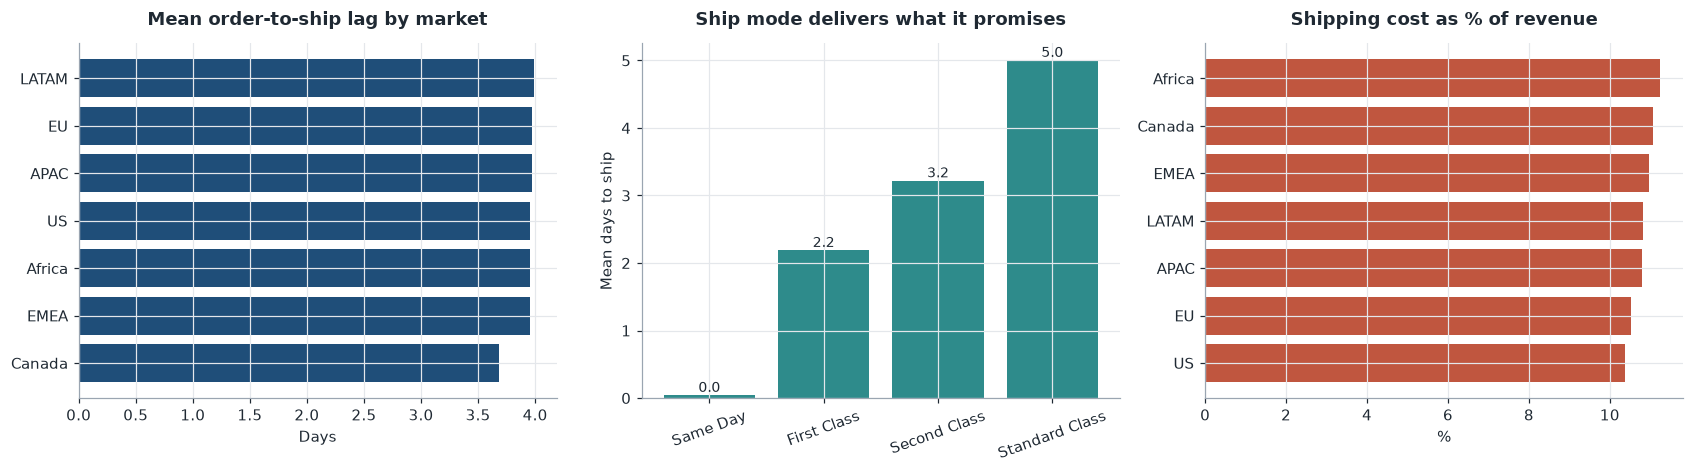

  shipping cost total : $1.4M (10.7% of revenue)
  ship lag range      : 0-7 days, mean 3.97

  NOTE: this is order-to-SHIP lag. The dataset has no delivery date, so true
  transit time and late-delivery rate are not computable and are not estimated.


In [24]:
# --- Figure 14: fulfilment ------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))

ax = axes[0]
lag_mode = orders.groupby("market")["ship_lag_days"].mean().sort_values()
ax.barh(lag_mode.index, lag_mode.values, color=PALETTE["primary"])
ax.set_title("Mean order-to-ship lag by market")
ax.set_xlabel("Days")

ax = axes[1]
ship = (lines.drop_duplicates("order_key")
        .groupby("ship_mode")["ship_lag_days"].agg(["mean", "size"])
        .sort_values("mean"))
ax.bar(ship.index, ship["mean"], color=PALETTE["accent"])
ax.set_title("Ship mode delivers what it promises")
ax.set_ylabel("Mean days to ship")
ax.tick_params(axis="x", rotation=20)
for i, v in enumerate(ship["mean"]):
    ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)

ax = axes[2]
shipcost = (lines.groupby("market")
            .apply(lambda d: d["shipping_cost"].sum() / d["revenue"].sum() * 100,
                   include_groups=False)
            .sort_values())
ax.barh(shipcost.index, shipcost.values, color=PALETTE["warn"])
ax.set_title("Shipping cost as % of revenue")
ax.set_xlabel("%")

fig.tight_layout()
save_fig(fig, "14_operations_fulfilment",
         "Is fulfilment speed or shipping cost a problem in any market?")
plt.show()

print(f"  shipping cost total : {money(lines['shipping_cost'].sum())} "
      f"({lines['shipping_cost'].sum()/lines['revenue'].sum():.1%} of revenue)")
print(f"  ship lag range      : {orders['ship_lag_days'].min()}-{orders['ship_lag_days'].max()} days, "
      f"mean {orders['ship_lag_days'].mean():.2f}")
print("\n  NOTE: this is order-to-SHIP lag. The dataset has no delivery date, so true")
print("  transit time and late-delivery rate are not computable and are not estimated.")

---
## 13. Business Insights

Every number below is computed in this notebook and re-asserted by
`src/verify_claims.py` against the processed data.

In [25]:
insights = {}

# 1 - growth vs margin
insights["revenue_2011"] = float(yearly.loc[2011, "revenue"])
insights["revenue_2014"] = float(yearly.loc[2014, "revenue"])
insights["revenue_growth_4yr_pct"] = float(
    (yearly.loc[2014, "revenue"] / yearly.loc[2011, "revenue"] - 1) * 100)
insights["margin_2011_pct"] = float(yearly.loc[2011, "margin_pct"])
insights["margin_2014_pct"] = float(yearly.loc[2014, "margin_pct"])

# 2 - discount
insights["total_discount_given"] = float(total_disc)
insights["discount_share_of_list_pct"] = float(total_disc / total_list * 100)
insights["spearman_discount_quantity"] = float(corr_qty.statistic)
insights["spearman_discount_margin"] = float(corr_margin.statistic)
insights["avg_qty_no_discount"] = float(no_disc["quantity"].mean())
insights["avg_qty_heavy_discount"] = float(heavy["quantity"].mean())
insights["margin_no_discount_pct"] = float(no_disc["profit"].sum() / no_disc["revenue"].sum() * 100)
insights["margin_heavy_discount_pct"] = float(heavy["profit"].sum() / heavy["revenue"].sum() * 100)

# 3 - loss making
insights["loss_making_lines"] = int(lines["is_loss_making"].sum())
insights["loss_making_share_pct"] = float(lines["is_loss_making"].mean() * 100)
insights["loss_total"] = float(lines.loc[lines["profit"] < 0, "profit"].sum())

# 4 - products
insights["danger_products"] = int(len(bad_q))
insights["danger_products_revenue"] = float(bad_q["revenue"].sum())
insights["danger_products_profit"] = float(bad_q["profit"].sum())

# 5 - concentration
insights["gini"] = float(gini)
insights["top20pct_revenue_share_pct"] = float(top20 / tot * 100)
insights["unprofitable_customers"] = int((customers["lifetime_profit"] < 0).sum())

# 6 - sub-categories and regions
insights["loss_sub_categories"] = loss_sub["sub_category"].tolist()
insights["loss_regions"] = reg[reg["profit"] < 0].index.tolist()

# 7 - returns
insights["return_rate_measured_pct"] = float(measured["return_flag"].mean() * 100)
insights["orders_without_returns_data"] = int(len(excluded))
insights["return_subcat_min_pct"] = float(all_sub.min())
insights["return_subcat_max_pct"] = float(all_sub.max())
insights["return_subcat_spread_ratio"] = float(all_sub.max() / all_sub.min())
insights["returned_order_revenue"] = float(
    measured.loc[measured["return_flag"] == 1, "order_value"].sum())

# discount bands above the 20% crossover, quoted in recommendation 1
heavy_bands = lines[lines["discount"] > 0.20]
insights["above20_discount_revenue"] = float(heavy_bands["revenue"].sum())
insights["above20_discount_profit"] = float(heavy_bands["profit"].sum())

# 8 - discount band economics
insights["loss_rate_no_discount_pct"] = float(
    lines.loc[lines["discount"] == 0, "is_loss_making"].mean() * 100)
insights["loss_rate_heavy_discount_pct"] = float(
    lines.loc[lines["discount"] > 0.5, "is_loss_making"].mean() * 100)
insights["danger_vs_healthy_discount_ratio"] = float(
    qsum.loc["High revenue / LOW profit", "avg_discount"]
    / qsum.loc["High revenue / High profit", "avg_discount"])
insights["danger_revenue_share_pct"] = float(
    bad_q["revenue"].sum() / prod["revenue"].sum() * 100)

# 8 - retention
insights["retention_trend_pp_per_month"] = float(slope)
insights["retention_trend_pvalue"] = float(p_val)
insights["mean_retention_pct"] = float(avg_ret.mean())

# 9 - headline
insights["total_revenue"] = float(total_rev)
insights["total_profit"] = float(total_profit)
insights["profit_margin_pct"] = float(total_profit / total_rev * 100)
insights["orders"] = int(n_orders)
insights["customers"] = int(customers["customer_key"].nunique())
insights["aov"] = float(orders["order_value"].mean())
insights["median_order_value"] = float(orders["order_value"].median())

(ROOT / "reports" / "insight_facts.json").write_text(
    json.dumps(insights, indent=2), encoding="utf-8")

for k, v in insights.items():
    print(f"  {k:<34} {v:,.4f}" if isinstance(v, float)
          else f"  {k:<34} {v}")

  revenue_2011                       2,259,450.8955
  revenue_2014                       4,299,865.8706
  revenue_growth_4yr_pct             90.3058
  margin_2011_pct                    11.0178
  margin_2014_pct                    11.7252
  total_discount_given               2,363,988.3201
  discount_share_of_list_pct         15.7531
  spearman_discount_quantity         0.0177
  spearman_discount_margin           -0.6691
  avg_qty_no_discount                3.4047
  avg_qty_heavy_discount             2.8449
  margin_no_discount_pct             25.3231
  margin_heavy_discount_pct          -111.0211
  loss_making_lines                  12544
  loss_making_share_pct              24.4570
  loss_total                         -920,646.1557
  danger_products                    1380
  danger_products_revenue            3,037,190.8834
  danger_products_profit             -461,720.2479
  gini                               0.1797
  top20pct_revenue_share_pct         30.0365
  unprofitable_custome

### The eight findings that matter

1. **Growth is real but unit economics are not improving.** Revenue rose 90% (\$2.26M ->
   \$4.30M) with growth accelerating to 26% a year, yet margin never left the 11.0%-12.0%
   band. The business is buying volume, not building profitability.

2. **Discounting buys nothing.** Spearman rho between discount and quantity is **+0.018** -
   economically meaningless - while discount vs margin is **-0.67**. Units per line are flat
   at 3.4-3.8 from 0% to 50% discount and then *fall* to 2.8 above 50%. **\$2.36M (15.8% of
   list revenue)** was given away for no volume gain. This is the largest recoverable sum in
   the dataset.

3. **The loss is entirely a discount phenomenon.** Of lines sold at full price, **0.0% lose
   money**. Of lines discounted above 50%, **100% lose money**. The crossover sits between the
   11-20% and 21-30% bands. Overall, 12,544 of 51,290 lines (24.5%) are unprofitable,
   totalling **-\$920K**.

4. **Only one sub-category destroys value: Tables** (-\$64K on \$757K revenue, -8.5% margin).
   And **no region or market is loss-making** - all 13 regions and all 7 markets are profitable.
   The weak spots are thin margins (Southeast Asia 2.0%, EMEA 5.5%), not negative ones. This
   is a pricing problem, not a footprint problem.

5. **The 80/20 rule does not apply.** Gini 0.18; the top 20% of customers hold 30% of revenue;
   lifetime revenue spans only ~10x across the whole base. There is no whale segment to
   protect, so value must come from economics that touch every customer.

6. **1,380 products are high-revenue but loss-making**, carrying **24.0% of all revenue**
   (\$3.04M) while destroying **\$462K** of profit. Their mean discount is **2.15x** that of
   the healthy high-revenue group - the same discount story, at product level.

7. **Retention shows no significant decay** (-0.21pp/month, p = 0.09) because this is a closed
   panel: observed retention ~44% tracks the ~49% Poisson purchase probability. Cohort
   analysis has no churn signal here.

8. **Neither fulfilment nor returns has a hotspot.** Ship lag is 0-7 days, ship modes behave
   exactly as labelled, and lag correlates with nothing. Return rates sit in a narrow 6.3-9.1%
   band across every sub-category (1.44x worst-to-best) and 5.4-6.2% across measured markets.
   Returns are a systemic cost of trading, not a product failure to hunt down.

---
## 14. Recommendations

Each recommendation names the action, the evidence, and the figure it comes from. Nothing
here is asserted without a number behind it.

| # | Recommendation | Evidence | Expected effect |
|---|---|---|---|
| 1 | **Cap discounts at 20%.** That is where the data puts the crossover: 0-20% bands are profitable, 21-30% turns negative, and above 50% every single line loses money. | S6: margin +25.3% -> -111.0%; loss rate 0.0% -> 100.0%; \$2.36M given away | Largest single lever. The 21%+ bands together carry \$1.93M revenue and **-\$815K** profit |
| 2 | **Run a controlled discount test before rolling that out.** Hold discount flat on a random half of one category for a quarter and measure units, not revenue. | The rho +0.018 result is observational; causation is not established | Converts an inference into a decision-grade result |
| 3 | **Reprice or delist the 1,380 high-revenue / loss-making products.** Do not scale them. | S11: 24.0% of revenue, -\$462K profit, 2.15x the discount of the healthy group | Directly removes the largest product-level loss |
| 4 | **Fix Tables; do not exit any region.** Tables is the only negative sub-category (-\$64K, -8.5%). Every region and market is profitable, so footprint exit is *not* warranted - but Southeast Asia (2.0%) and EMEA (5.5%) need margin review. | S6: 1 negative sub-category, 0 negative regions, 0 negative markets | Removes a contained loss without a costly and unjustified retreat |
| 5 | **Do not build the strategy on customer tiering.** With Gini 0.18 and the top 20% holding 30%, there is no top-tier to defend; pricing and range fixes reach everyone at once. | S8: top 20% hold 30.0%, not 80% | Avoids funding a segmentation this data does not support |
| 6 | **Put the 67 unprofitable customers on commercial review** - minimum order values, shipping recovery, or discount withdrawal. | S8: negative lifetime profit despite real revenue | Converts a known drain toward break-even |
| 7 | **Treat returns as a systemic cost, not a hunt.** At 5.8% of orders with a 6.3-9.1% spread across all 17 sub-categories, there is no hotspot to root-cause. Price the ~\$818K of returned-order revenue into margin planning instead. | S12: 1.44x worst-to-best ratio; no market or category outlier | Stops a root-cause programme that would find nothing |
| 8 | **Instrument what is missing before the next review.** Capture payment method, order status/cancellations, delivery dates, and returns in Africa/Canada/EMEA. | S3, S12: four brief questions were unanswerable; 5,037 orders have no returns data | Makes the next cycle answerable rather than caveated |

### What this analysis deliberately did not do

- **No payment-method or cancellation analysis.** Neither field exists. Approximating them
  would have been invention.
- **No delivery-time or late-delivery metric.** Only ship date exists; order-to-ship lag is
  reported under its real name.
- **No return rate for Africa, Canada or EMEA.** No return records exist for those markets;
  they are excluded from rates rather than shown as 0%.
- **No customer demographics.** No gender or age field exists, so no demographic segmentation
  is offered.
- **No predictive churn model.** With one customer dormant beyond 180 days there is no
  meaningful churn label to train on. Saying so is more useful than fitting a model to noise.

In [26]:
print("FIGURE INDEX - every chart and the question it answers")
print("=" * 78)
for name, question in FIG_INDEX.items():
    print(f"  {name:<34} {question}")
print(f"\n{len(FIG_INDEX)} figures written to reports/figures/")

FIGURE INDEX - every chart and the question it answers
  01_monthly_revenue_profit          How is the business performing over time?
  02_yearly_growth                   Is growth accelerating, and is margin improving with scale?
  03_univariate_distributions        What does a typical order, discount, margin and fulfilment lag look like?
  04_category_profitability          Which categories and sub-categories generate profit, not just revenue?
  05_market_region_performance       Which markets and regions perform best, and which lose money?
  06_discount_effectiveness          Do discounts buy volume, or just give away margin?
  07_correlation_matrix              Which measures genuinely move together, once arithmetic links are set aside?
  08_customer_concentration          Is revenue concentrated in a few customers, as the 80/20 rule assumes?
  09_rfm_segments                    How does the customer base split by engagement and value, and what is each worth?
  10_cohort_retention_